# Flow in the Viane experience-sampling data: operationalization, analysis, and conclusions

**Project 21.** Viane et al. (2004, *Pain*) / Crombez et al. (2013). Palmtop experience sampling,
8 random beeps per day plus a morning and an evening diary, 14 days.

---

## What this notebook is

A complete, self-contained technical analysis of whether and how the psychological construct of
**flow** can be operationalized in this dataset, and what it shows once it is. It is written to be
read end to end by someone deciding whether the construct earns a place in the manuscript. Every
number in the conclusions is produced by a cell here, and every methodological choice is stated
together with the alternative that was not taken and the reason.

**Nothing from this analysis has been written into the manuscript.** The analysis is finished and
the figures and tables exist; the decision to use them is deliberately left open.

## How to read it

| Section | Question it answers |
| --- | --- |
| 1 | What is flow, and which items measure it here? |
| 2 | What does the analytic dataset look like: sample, compliance, missingness? |
| 3 | Which standardization, and why is that the most consequential choice? |
| 4 | How exactly are the flow variables built? |
| 5 | **V1.** Does this population experience flow at all, and how often? |
| 6 | **V2.** Does the flow model behave as theory predicts? |
| 7 | **V3.** Is there temporal structure, and does it differ per person? |
| 8 | Does flow relate to the momentary experience of pain? |
| 9 | Does flow proneness relate to baseline trait profiles? |
| 10 | Do the conclusions survive every alternative choice? |
| 11 | Decision log: every choice in one table |
| 12 | Conclusions and interpretation |
| 13 | Caveats that must travel with any reported result |
| A | Cross-validation against the independent R implementation |

## Headline findings, stated up front

1. **The construct is available and the operationalization is sound.** Four momentary items cover
   the antecedent condition and the core experience: 5,976 moments in 68 persons, with roughly 78
   percent of the variance sitting within person.
2. **The flow model only half holds.** The challenge-skill condition predicts the flow experience
   very strongly, but entirely through *elevation* (both high) and not through *balance* (matched).
   Between persons, and on the raw scale, the balance effect is significantly **negative**, which
   is a reversal of the theory rather than an absence of support.
3. **Flow relates to the momentary experience of pain, concurrently and significantly.** A higher
   than usual flow experience goes with lower pain, lower interference, less attention to pain,
   and lower threat, all p < .001, unchanged after adjusting for physical activation.
4. **Temporal structure is almost absent.** Within the flow model there is a small but significant
   lagged path from condition to experience (b = 0.051, p = .039). Between flow and pain there is
   nothing at lag 1 in either direction. The flow-pain relation is strictly concurrent.
5. **The flow-pain association is strongly person-specific.** 73 percent of participants show the
   negative pattern, 14 of 63 reliably so, but 4 show a reliably positive one.
6. **The relaxation channel outperforms flow on every pain outcome.** In chronic pain the
   protective ingredient looks like competence without demand, not optimal challenge.

## Reproducibility

The R pipeline one directory up in `12_flow_states/` remains the analysis of record and runs inside
`make run-all`. This notebook re-estimates every model independently in Python, so that the analysis
can be read in full without an R installation and so that the two implementations check each other:
different optimisers, and Wald z tests here against Satterthwaite t tests there. Appendix A compares
them coefficient by coefficient. The within-person estimates and all flow-to-pain estimates agree to
three decimals; the two between-person terms differ by up to 0.008 for a documented data-preparation
reason. Figures are written to `figures/` next to this notebook.

---
# 0. Setup

In [1]:
from __future__ import annotations

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy import stats

warnings.filterwarnings("ignore")
pd.set_option("display.width", 130)
pd.set_option("display.max_columns", 40)
np.random.seed(20260703)

# This notebook lives at src/utils/pipeline/separate/12_flow_states/flow_analysis/
ROOT = Path.cwd()
while not (ROOT / "src" / "data" / "processed").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

EMA = ROOT / "src" / "data" / "processed" / "ema_long.csv"
PERSON = ROOT / "src" / "data" / "processed" / "person_level.csv"
TABLES = ROOT / "src" / "results" / "tables"
FIGDIR = Path.cwd() / "figures"
FIGDIR.mkdir(exist_ok=True)

print("project root :", ROOT)
print("diary file   :", EMA.relative_to(ROOT))
print("figures ->   :", FIGDIR.name + "/")

project root : /Users/stijnvanseveren/PROJECTS/summer_2026/CROMBEZ_MAP/04_Viane_EMA
diary file   : src/data/processed/ema_long.csv
figures ->   : figures/


In [2]:
# Visual identity, matched to the manuscript figures so panels can be lifted directly.
INK, MUTED, GRID = "#1d2733", "#5b6b7b", "#dfe5ec"
COL = {"PIJN": "#c1483f", "THREAT": "#9b59b6", "ATTEND": "#2a7f9e",
       "ENGAGE": "#3a9e6e", "EFFIC": "#d98a3d", "VALENCE": "#8a6d3b",
       "CHALLENGE": "#7a5ea8", "FLOWEXP": "#4f8f5a",
       "balance": "#6b8fae", "elevation": "#c98a2b"}
CHANNEL_COL = {"Flow": "#3a9e6e", "Relaxation": "#6b8fae",
               "Anxiety": "#c1483f", "Apathy": "#9aa5b1"}
CHANNELS = ["Flow", "Relaxation", "Anxiety", "Apathy"]
LABEL = {"PIJN": "Pain intensity", "PIJN_AFF": "Pain interference",
         "ATTEND": "Attention to pain", "THREAT": "Threat value",
         "CHALLENGE": "Challenge", "EFFIC": "Skill", "ENGAGE": "Absorption",
         "VALENCE": "Enjoyment", "FLOWEXP": "Flow experience"}

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
    "figure.facecolor": "white", "axes.facecolor": "white",
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
    "axes.edgecolor": MUTED, "axes.linewidth": 0.8, "axes.labelcolor": INK,
    "axes.titlecolor": INK, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.7,
    "legend.frameon": False, "legend.fontsize": 9})


def panel(ax, letter, dx=-0.10, dy=1.08):
    ax.text(dx, dy, letter, transform=ax.transAxes, fontsize=13, fontweight="bold",
            va="top", ha="right", color=INK)


def bar_axes(ax, horizontal=False):
    ax.grid(axis="x" if horizontal else "y", visible=True)
    ax.grid(axis="y" if horizontal else "x", visible=False)


def matrix_axes(ax):
    ax.grid(False)
    for sp in ax.spines.values():
        sp.set_visible(False)
    ax.tick_params(length=0)


def show(fig, name):
    fig.savefig(FIGDIR / f"{name}.png")
    plt.show()


def fmt_p(p):
    if pd.isna(p):
        return ""
    return "<.001" if p < .001 else f"{p:.3f}".lstrip("0")

In [3]:
# Model helpers used throughout. Multilevel models are statsmodels MixedLM with participant
# random effects; random slopes are requested through re_formula. Tests are Wald z tests.

def mixed(formula, data, re_formula=None, reml=True):
    '''Fit a MixedLM with participants as the grouping factor, dropping incomplete rows first.'''
    terms = set()
    for tok in formula.replace("~", "+").replace("*", "+").replace(":", "+").split("+"):
        tok = tok.strip()
        if tok and tok in data.columns:
            terms.add(tok)
    if re_formula:
        for tok in re_formula.replace("~", "+").split("+"):
            tok = tok.strip()
            if tok and tok in data.columns:
                terms.add(tok)
    dd = data.dropna(subset=list(terms)).copy()
    fit = smf.mixedlm(formula, dd, groups=dd["pid"], re_formula=re_formula).fit(reml=reml)
    fit._n_obs = len(dd)
    fit._n_grp = dd["pid"].nunique()
    return fit


def tidy(fit, keep=None, label=""):
    '''Fixed effects of a fitted MixedLM as a tidy, print-ready frame.'''
    out = pd.DataFrame({"term": fit.params.index, "b": fit.params.values,
                        "SE": fit.bse.values, "z": fit.tvalues.values,
                        "p": fit.pvalues.values})
    out = out[~out["term"].str.contains("Var|Cov", regex=True)]
    if keep is not None:
        out = out[out["term"].isin(keep)]
    out["b"] = out["b"].round(3)
    out["SE"] = out["SE"].round(3)
    out["z"] = out["z"].round(2)
    out["p"] = out["p"].map(fmt_p)
    if label:
        out.insert(0, "model", label)
    return out.reset_index(drop=True)


def random_sd(fit, term):
    '''Standard deviation of a random slope. MixedLM stores the covariance scaled by sigma^2.'''
    cov = fit.cov_re
    if term not in cov.index:
        return np.nan
    return float(np.sqrt(cov.loc[term, term] * fit.scale))


def within_center(s, g):
    return s - s.groupby(g).transform("mean")


def between_mean(s, g):
    return s.groupby(g).transform("mean")


def within_z(s, g):
    mu = s.groupby(g).transform("mean")
    sd = s.groupby(g).transform("std").replace(0, np.nan).fillna(1.0)
    return (s - mu) / sd

---
# 1. The construct and the instrument

## 1.1 Definition

Flow, in Csikszentmihalyi's sense, is a state of **deep absorption and effortless concentration**
that arises when perceived challenge and perceived skill are both high and roughly matched, and
that is experienced as intrinsically rewarding, or autotelic.

The construct has two structurally distinct parts, and keeping them apart is the whole
methodological game:

- an **antecedent condition**, the configuration of challenge and skill, and
- the **experience** itself, absorption plus enjoyment.

Collapsing the two into one sum score conflates the cause with the outcome and is theoretically
incoherent. Every analysis below keeps them separate.

## 1.2 The four items

All four are 7-point momentary appraisals of the activity the participant was engaged in at the
beep, anchored "not at all" to "very much". Challenge and skill descend from the Delespaul ESM
tradition; absorption and enjoyment were assigned by the original authors to Klinger's
goal-directed framework.

| Facet, and its role in the flow model | Item (EN) | Item (NL) | Column (raw) |
| --- | --- | --- | --- |
| Challenge, antecedent condition | This activity is a personal challenge to me | Deze activiteit is een persoonlijke uitdaging voor mij | `CHALLENGE` (`ACT_UITD`) |
| Skill / efficacy, antecedent condition | I am good at it | Ik kan dit goed | `EFFIC` (`ACT_SUC`) |
| Absorption / engagement, core experience | I am absorbed in this activity | Ik ga op in deze activiteit | `ENGAGE` (`ACT_AAND`) |
| Valence / enjoyment, autotelic marker | I like doing this | Ik doe dit graag | `VALENCE` (`ACT_MOT`) |

A fifth activity item, goal importance (`ACT_INSP`), exists. It belongs to the Klinger goal
framework rather than to flow, and is not part of any flow index here.

## 1.3 Coverage against the nine flow dimensions

This determines how the construct may be labelled in a manuscript.

| Csikszentmihalyi dimension | Measured here? |
| --- | --- |
| Challenge-skill balance | Yes, directly |
| Concentration, action-awareness merging | Partly, through absorption |
| Autotelic experience | Partly, through enjoyment |
| Clear goals | No. A goal-importance item exists, but importance is not clarity |
| Unambiguous feedback | No |
| Sense of control | No. The control items in this dataset concern control over *pain*, not over the task |
| Loss of self-consciousness | No |
| Time transformation | No |
| Intrinsic reward | Partly, through enjoyment |

**Consequence.** Three of nine dimensions plus the defining antecedent condition, from four single
items. The honest label is a **core flow proxy**, never "a measure of flow". This is not a
weakness peculiar to this dataset: the ESM flow tradition (Massimini and Carli, 1988; Moneta and
Csikszentmihalyi, 1996) has always measured flow from exactly challenge, skill, and a small set of
experience items. The full multi-item instruments (for example the Flow State Scale-2) exist, but
no ESM protocol of this vintage carried them.

## 1.4 Provenance caveat

The original study analysed these four items **separately** and never combined them into a flow
score. Every index in this notebook is therefore a secondary, analyst-constructed measure and must
be reported as such. This is an analysis decision, not a re-coding of the source data.

## 1.5 Key references

- Csikszentmihalyi, M. (1990). *Flow: The Psychology of Optimal Experience*. Harper & Row.
- Csikszentmihalyi, M., & Larson, R. (1987). Validity and reliability of the Experience-Sampling
  Method. *Journal of Nervous and Mental Disease*, 175(9), 526-536.
  [doi:10.1097/00005053-198709000-00004](https://doi.org/10.1097/00005053-198709000-00004)
- Massimini, F., & Carli, M. (1988). The systematic assessment of flow in daily experience. In
  *Optimal Experience*. Cambridge University Press.
  [doi:10.1017/CBO9780511621956.014](https://doi.org/10.1017/CBO9780511621956.014)
- Moneta, G. B., & Csikszentmihalyi, M. (1996). The effect of perceived challenges and skills on
  the quality of subjective experience. *Journal of Personality*, 64(2), 275-310.
  [doi:10.1111/j.1467-6494.1996.tb00512.x](https://doi.org/10.1111/j.1467-6494.1996.tb00512.x)
- Fong, C. J., Zaleski, D. J., & Leach, J. K. (2015). The challenge-skill balance and antecedents
  of flow: a meta-analytic investigation. *Journal of Positive Psychology*, 10(5), 425-446.
  [doi:10.1080/17439760.2014.967799](https://doi.org/10.1080/17439760.2014.967799)
- Nakamura, J., & Csikszentmihalyi, M. (2014). The concept of flow. In *Flow and the Foundations
  of Positive Psychology*. Springer.
  [doi:10.1007/978-94-017-9088-8_16](https://doi.org/10.1007/978-94-017-9088-8_16)
- Jackson, S. A., & Eklund, R. C. (2002). Assessing flow in physical activity: the Flow State
  Scale-2. *Journal of Sport and Exercise Psychology*, 24(2), 133-150.
  [doi:10.1123/jsep.24.2.133](https://doi.org/10.1123/jsep.24.2.133)
- Curran, P. J., & Bauer, D. J. (2011). The disaggregation of within-person and between-person
  effects in longitudinal models of change. *Annual Review of Psychology*, 62, 583-619.
  [doi:10.1146/annurev.psych.093008.100356](https://doi.org/10.1146/annurev.psych.093008.100356)
- Gromakovskis, V., & Gutmanis, M. G. (2025). Flow-induced analgesia: a conceptual review of
  biopsychosocial and neurobiological mechanisms of pain modulation. *Journal of Pain Research*,
  18, 6723-6743. [doi:10.2147/JPR.S564395](https://doi.org/10.2147/JPR.S564395)
- Eccleston, C., & Crombez, G. (1999). Pain demands attention: a cognitive-affective model of the
  interruptive function of pain. *Psychological Bulletin*, 125(3), 356-366.
  [doi:10.1037/0033-2909.125.3.356](https://doi.org/10.1037/0033-2909.125.3.356)
- Van Damme, S., Legrain, V., Vogt, J., & Crombez, G. (2010). Keeping pain in mind: a motivational
  account of attention to pain. *Neuroscience and Biobehavioral Reviews*, 34(2), 204-213.
  [doi:10.1016/j.neubiorev.2009.01.005](https://doi.org/10.1016/j.neubiorev.2009.01.005)
- Viane, I., Crombez, G., Eccleston, C., Devulder, J., & De Corte, W. (2004). Acceptance of the
  unpleasant reality of chronic pain. *Pain*, 112(3), 282-288.
  [doi:10.1016/j.pain.2004.09.008](https://doi.org/10.1016/j.pain.2004.09.008)

---
# 2. Data preparation

Four preparatory questions have to be settled before any modelling: what counts as a valid
response, what compliance minimum applies, how the nesting is handled, and whether missingness is
informative.

In [4]:
ema = pd.read_csv(EMA)
ITEMS = ["CHALLENGE", "EFFIC", "ENGAGE", "VALENCE"]
CONDITION_ITEMS = ["CHALLENGE", "EFFIC"]
EXPERIENCE_ITEMS = ["ENGAGE", "VALENCE"]

print(f"diary rows (completed prompts) : {len(ema):,}")
print(f"participants                   : {ema['pid'].nunique()}")
sz = ema.groupby("pid").size()
print(f"prompts per person             : median {sz.median():.0f}, "
      f"range {sz.min()} to {sz.max()}")

display(pd.DataFrame({
    "item": ITEMS,
    "role": ["condition", "condition", "experience", "experience"],
    "n present": [int(ema[i].notna().sum()) for i in ITEMS],
    "% missing": [round(100 * ema[i].isna().mean(), 1) for i in ITEMS],
}))

diary rows (completed prompts) : 6,262
participants                   : 68
prompts per person             : median 96, range 30 to 122


,item,role,n present,% missing
0,CHALLENGE,condition,6165,1.5
1,EFFIC,condition,6108,2.5
2,ENGAGE,experience,6143,1.9
3,VALENCE,experience,6136,2.0


## 2.1 Valid response

The intended rule is to keep beep answers given inside a 15-minute protocol window and to treat
late or absent beeps as missing.

**This cannot be reconstructed from the archived data.** The raw day file
(`src/data/raw/diary_day.sav`) contains a single time variable, `UUR`, which records the clock
time of the *entry*. There is no separate signal timestamp, so response latency is not recoverable
and no 15-minute rule can be applied.

**Decision taken.** Use the project's existing definition of a completed prompt, namely that the
core pain item was answered. This has the additional advantage that the flow analysis runs on
exactly the same sample as the rest of the study, so estimates are directly comparable across
sections of the manuscript. This is a documented deviation, forced by the archive rather than
chosen, and it belongs in the limitations.

In [5]:
# Analytic frame: complete cases on all four flow items.
flow_cc = ema[ITEMS].notna().all(axis=1)
f = ema[flow_cc].copy().reset_index(drop=True)

n_per = f.groupby("pid").size()
print(f"analytic frame : {len(f):,} moments, {f['pid'].nunique()} persons")
print(f"per person     : median {n_per.median():.0f}, "
      f"IQR {n_per.quantile(.25):.0f} to {n_per.quantile(.75):.0f}, "
      f"range {n_per.min()} to {n_per.max()}")
print(f"listwise loss  : {len(ema) - len(f):,} moments "
      f"({100 * (1 - len(f) / len(ema)):.1f}% of completed prompts)")

analytic frame : 5,976 moments, 68 persons
per person     : median 92, IQR 82 to 99, range 25 to 121
listwise loss  : 286 moments (4.6% of completed prompts)


## 2.2 Compliance minimum

The specification suggests at least 20 to 30 valid moments per person before any person-level
estimate is trusted.

**Decision taken: 50 moments**, the project's existing idiographic floor. Stricter than the
suggestion, and it keeps the flow analysis consistent with the idiographic stages of the study.
The multilevel models use every participant, because partial pooling stabilises short series; the
per-person analyses in section 7 apply the 50-moment floor. Section 10.4 re-runs the headline
result at 20, 30, 50, and 70 to show the choice does not drive it.

In [6]:
rows = []
for thr in [20, 30, 50, 70]:
    keep = n_per[n_per >= thr].index
    rows.append({"threshold": f">= {thr}", "persons retained": len(keep),
                 "persons dropped": len(n_per) - len(keep),
                 "moments retained": int(f["pid"].isin(keep).sum())})
display(pd.DataFrame(rows))

,threshold,persons retained,persons dropped,moments retained
0,>= 20,68,0,5976
1,>= 30,67,1,5951
2,>= 50,63,5,5779
3,>= 70,61,7,5660


## 2.3 Nesting

Moments (level 1) are nested in persons (level 2). Every model below carries participant random
effects. Day and beep number are available as level-1 covariates; section 10.3 tests whether
adding them changes anything. It does not, so the reported models leave them out for readability.

## 2.4 Missingness

In a chronic pain sample, non-response may be informative: high-pain, low-activity moments are
plausibly the ones most likely to be skipped. If so, flow prevalence would be biased upward. The
check below compares the moments where the flow items are missing against those where they are
present, on the variables recorded in both.

In [7]:
miss_rows = []
for v in ["PIJN", "PIJN_AFF", "ATTEND", "THREAT", "NEGAFF", "POSAFF", "ACTIEF"]:
    a = ema.loc[flow_cc, v].dropna()
    b = ema.loc[~flow_cc, v].dropna()
    if len(b) < 10:
        continue
    t, p = stats.ttest_ind(a, b, equal_var=False)
    pooled = np.sqrt((a.var(ddof=1) + b.var(ddof=1)) / 2)
    miss_rows.append({"variable": LABEL.get(v, v),
                      "flow items present": round(a.mean(), 2),
                      "flow items missing": round(b.mean(), 2),
                      "n missing": len(b),
                      "Cohen d": round((b.mean() - a.mean()) / pooled, 3),
                      "p": fmt_p(p)})
display(pd.DataFrame(miss_rows))

,variable,flow items present,flow items missing,n missing,Cohen d,p
0,Pain intensity,4.53,4.36,286,-0.115,.052
1,Pain interference,3.86,3.79,272,-0.043,.476
2,Attention to pain,2.89,2.95,255,0.034,.593
3,Threat value,2.23,2.44,268,0.151,.019
4,NEGAFF,1.92,2.14,280,0.193,.002
5,POSAFF,4.23,4.27,286,0.033,.583
6,ACTIEF,3.05,2.62,274,-0.235,<.001


**Reading of the missingness check.** Listwise deletion removes 4.6 percent of completed prompts
(286 moments). Those moments are not a random subset, but the pattern is mild and mixed. Threat
value (d = 0.15, p = .019) and negative affect (d = 0.19, p = .002) are slightly *higher* at
skipped moments, while pain intensity is marginally *lower* (d = -0.12, p = .053) and
interference, attention, and positive affect do not differ.

So the skipped moments look somewhat more distressed but not more painful. Two consequences worth
carrying forward. First, prevalence figures in section 5 may be very slightly optimistic. Second,
because the deviation is on threat and negative affect rather than pain, the concurrent flow-pain
estimate in section 8 is unlikely to be materially biased. This is a small, documented, and
directionally understood loss rather than a threat to the analysis.

---
# 3. The standardization decision

This is the single choice that most often produces interpretation errors in ESM flow research, so
it is settled explicitly and before anything is estimated.

**The problem.** Within-person z-scoring sets every person's mean to exactly zero. Any rule of the
form "challenge above the person's own average and skill above the person's own average"
therefore assigns above-average moments to *everyone*, including someone who was never in flow in
any absolute sense. For a prevalence question that is not a technicality, it is a structural bias.

## The four options

| | What it does | Pro | Con |
| --- | --- | --- | --- |
| **A. Raw absolute** (thresholds on 1 to 7) | keeps the absolute level | a person genuinely *can* have zero flow moments; directly interpretable on the response scale; comparable across persons | sensitive to response style and range restriction; the threshold (4 or 5) is arbitrary and matters a lot |
| **B. Grand-mean z** (pooled over the sample) | one common metric | keeps between-person level differences; simple | does not correct response style; z is relative to *this* sample; mixes within and between variance in one number |
| **C. Within-person z** | removes response style and personal scale calibration | the ESM flow standard; ideal for within-person relations | forces a relative distribution, so it manufactures flow moments for everyone; ipsative and not comparable across persons; unstable with few moments |
| **D. Person-mean centering** (within-between decomposition) | splits the person mean from the momentary deviation | answers the prevalence and the dynamics question separately; the multilevel standard (Curran and Bauer); combines cleanly with random slopes | more complex to report; the between component is still response-style sensitive |

## Decision taken

**D as the primary metric, A as the metric for every prevalence claim, and B and C as sensitivity
analyses.** Section 10.1 refits the main model on all four and reports whether anything changes.

Note that C and D produce **identical channel assignments**, because within-person z is a positive
rescaling of the person-mean-centred score and so cannot change the sign of a deviation. They
differ only in the size of the model coefficients. That is why both appear in the sensitivity
table but only one prevalence row.

The demonstration below is the empirical justification for this decision.

In [8]:
g = f["pid"]

# Build all four metrics for the two condition items and the two experience items.
for v in ITEMS:
    f[v + "_w"] = within_center(f[v], g)          # D, within component
    f[v + "_b"] = between_mean(f[v], g)           # D, between component
    f[v + "_z"] = within_z(f[v], g)               # C
    f[v + "_gz"] = (f[v] - f[v].mean()) / f[v].std()   # B

print("metrics built for:", ", ".join(ITEMS))
print("suffixes: _w person-mean centred (D), _b person mean (D), "
      "_z within-person z (C), _gz grand-mean z (B), bare = raw (A)")

metrics built for: CHALLENGE, EFFIC, ENGAGE, VALENCE
suffixes: _w person-mean centred (D), _b person mean (D), _z within-person z (C), _gz grand-mean z (B), bare = raw (A)


In [9]:
# Why within-person standardization cannot answer a prevalence question.
demo = []
for rule, ch, sk, cut in [
        ("A raw, both >= 4", f["CHALLENGE"], f["EFFIC"], 4),
        ("A raw, both >= 5", f["CHALLENGE"], f["EFFIC"], 5),
        ("B grand-mean z, both > 0", f["CHALLENGE_gz"], f["EFFIC_gz"], 0),
        ("C within-person z, both > 0", f["CHALLENGE_z"], f["EFFIC_z"], 0),
        ("D person-mean centred, both > 0", f["CHALLENGE_w"], f["EFFIC_w"], 0)]:
    is_flow = (ch >= cut) & (sk >= cut)
    per_person = is_flow.groupby(g).mean()
    demo.append({"rule": rule,
                 "% of moments": round(100 * is_flow.mean(), 1),
                 "median person %": round(100 * per_person.median(), 1),
                 "persons at exactly 0%": int((per_person == 0).sum()),
                 "lowest person %": round(100 * per_person.min(), 1)})
demo = pd.DataFrame(demo)
display(demo)

,rule,% of moments,median person %,persons at exactly 0%,lowest person %
0,"A raw, both >= 4",39.6,37.3,0,1.0
1,"A raw, both >= 5",22.0,18.4,3,0.0
2,"B grand-mean z, both > 0",30.6,29.8,1,0.0
3,"C within-person z, both > 0",29.1,29.9,0,3.0
4,"D person-mean centred, both > 0",29.1,29.9,0,3.0


**This table is the argument.** Under the strict absolute rule, three participants never once rate
both challenge and skill at 5 or above, and a fourth drops out once the experience gate is applied
in section 5. For them the honest answer to "does this person experience flow" is no. Under
within-person z and person-mean centering, **zero** participants are at zero and even the lowest
person is credited with 3 percent of their moments as flow. The relative metrics
cannot represent absence. They are the right tool for within-person dynamics and the wrong tool
for prevalence, exactly as the specification warns.

---
# 4. Building the flow variables

## 4.1 The condition: balance and elevation, not a sum

Challenge and skill do not combine linearly. High challenge with low skill is anxiety; low
challenge with high skill is relaxation or boredom; both low is apathy. A simple sum of challenge
and skill is therefore **not** a flow condition.

Two parameterizations are carried:

**Option 1, the categorical quadrant** (Massimini and Carli, 1988). A moment is flow when
challenge and skill are both above a cut, and anxiety, relaxation, or apathy otherwise.
Established and easy to communicate, but it dichotomises continuous information and loses power.

**Option 2, continuous balance and elevation** (Moneta and Csikszentmihalyi, 1996), used as the
primary specification:

$$\text{balance} = -\lvert \text{challenge} - \text{skill}\rvert \qquad
\text{elevation} = \frac{\text{challenge} + \text{skill}}{2}$$

Balance is higher when the two are better matched; elevation is higher when both are high. **The
elevation term is not optional**: balance on its own would score a low-challenge, low-skill moment,
that is apathy, as perfectly balanced.

## 4.2 The experience: absorption gated by enjoyment

$$\text{flow experience} = \frac{\text{absorption} + \text{enjoyment}}{2}$$

The enjoyment term matters especially in a pain context, where high challenge can coincide with
threat and effortful struggle rather than positive engrossment. Enjoyment is what separates flow
from grinding.

## 4.3 Index versus model

Both routes are implemented, because they answer different questions.

- **Gated flow index**, descriptive, for V1. A moment counts as flow when the challenge-skill
  condition is met **and** the flow experience is high. The gate blocks the "balanced but
  disengaged" false positive that an unguarded quadrant produces.
- **Model test**, explanatory and stronger, for V2. Condition as predictor, experience as outcome,
  multilevel with random slopes. This tests whether the flow model holds without assigning flow
  moments to anybody by construction.

**Never done: summing the four items into one score.** That conflates the antecedent with the
outcome.

In [10]:
# Flow experience, on every metric.
f["FLOWEXP"] = f[EXPERIENCE_ITEMS].mean(axis=1)
f["FLOWEXP_w"] = within_center(f["FLOWEXP"], g)
f["FLOWEXP_b"] = between_mean(f["FLOWEXP"], g)
f["FLOWEXP_z"] = within_z(f["FLOWEXP"], g)
f["FLOWEXP_gz"] = (f["FLOWEXP"] - f["FLOWEXP"].mean()) / f["FLOWEXP"].std()

# Condition terms, on every metric.
def cond_terms(ch, sk):
    return -(ch - sk).abs(), (ch + sk) / 2

f["balance_raw"], f["elevation_raw"] = cond_terms(f["CHALLENGE"], f["EFFIC"])
f["balance_w"], f["elevation_w"] = cond_terms(f["CHALLENGE_w"], f["EFFIC_w"])
f["balance_z"], f["elevation_z"] = cond_terms(f["CHALLENGE_z"], f["EFFIC_z"])
f["balance_gz"], f["elevation_gz"] = cond_terms(f["CHALLENGE_gz"], f["EFFIC_gz"])
f["balance_b"], f["elevation_b"] = cond_terms(f["CHALLENGE_b"], f["EFFIC_b"])

# Covariates carried through the analysis.
for v in ["PIJN", "PIJN_AFF", "ATTEND", "THREAT", "ACTIEF"]:
    f[v + "_w"] = within_center(f[v], g)
    f[v + "_z"] = within_z(f[v], g)

print("derived variables built. Analytic frame:", f.shape)

derived variables built. Analytic frame: (5976, 77)


In [11]:
def channel(ch, sk, cut=0.0):
    '''Four-channel classification (Massimini and Carli, 1988).'''
    hc, hs = ch >= cut, sk >= cut
    out = np.where(hc & hs, "Flow",
          np.where(hc & ~hs, "Anxiety",
          np.where(~hc & hs, "Relaxation", "Apathy")))
    return pd.Categorical(out, categories=CHANNELS, ordered=False)


RULES = {
    "A_abs4":   ("A. Absolute, both >= 4", "CHALLENGE", "EFFIC", "FLOWEXP", 4.0),
    "A_abs5":   ("A. Absolute, both >= 5", "CHALLENGE", "EFFIC", "FLOWEXP", 5.0),
    "B_grandz": ("B. Grand-mean z", "CHALLENGE_gz", "EFFIC_gz", "FLOWEXP_gz", 0.0),
    "C_withinz": ("C. Within-person z", "CHALLENGE_z", "EFFIC_z", "FLOWEXP_z", 0.0),
    "D_center": ("D. Person-mean centred", "CHALLENGE_w", "EFFIC_w", "FLOWEXP_w", 0.0),
}

for key, (lab, ch, sk, exp, cut) in RULES.items():
    f["chan_" + key] = channel(f[ch], f[sk], cut)
    # experience gate on the same metric as the condition
    f["flow_" + key] = ((f["chan_" + key] == "Flow") & (f[exp] >= cut)).astype(int)

print("channel and gated-flow variables built for all five rules")
display(f[["CHALLENGE", "EFFIC", "ENGAGE", "VALENCE", "FLOWEXP",
           "balance_w", "elevation_w", "chan_D_center", "flow_A_abs5"]].head())

channel and gated-flow variables built for all five rules


,CHALLENGE,EFFIC,ENGAGE,VALENCE,FLOWEXP,balance_w,elevation_w,chan_D_center,flow_A_abs5
0,1.0,3.0,4.0,4.0,4.0,-0.170213,-1.553191,Apathy,0
1,1.0,7.0,7.0,7.0,7.0,-4.170213,0.446809,Relaxation,0
2,1.0,4.0,4.0,4.0,4.0,-1.170213,-1.053191,Apathy,0
3,1.0,5.0,7.0,7.0,7.0,-2.170213,-0.553191,Relaxation,0
4,1.0,6.0,7.0,6.0,6.5,-3.170213,-0.053191,Relaxation,0


In [12]:
# Item-level descriptives and the within-person variance share.
desc = []
for v in ITEMS + ["FLOWEXP"]:
    x = ema[v] if v in ema.columns else f[v]
    pm = x.groupby(ema["pid"] if v in ema.columns else g).mean()
    icc = pm.var() / x.var()
    desc.append({"variable": LABEL[v], "role": "condition" if v in CONDITION_ITEMS
                 else "experience", "n": int(x.notna().sum()),
                 "M": round(x.mean(), 2), "SD": round(x.std(), 2),
                 "ICC (person)": round(icc, 3), "within share": round(1 - icc, 3)})
desc = pd.DataFrame(desc)
display(desc)

,variable,role,n,M,SD,ICC (person),within share
0,Challenge,condition,6165,3.28,1.98,0.242,0.758
1,Skill,condition,6108,4.79,1.55,0.226,0.774
2,Absorption,experience,6143,4.00,1.90,0.213,0.787
3,Enjoyment,experience,6136,4.90,1.58,0.207,0.793
4,Flow experience,experience,5976,4.45,1.51,0.202,0.798


**Feasibility, settled.** Every flow item has an ICC around .20 to .24, so roughly 76 to 80
percent of its variance is within person. Flow in this dataset is genuinely a fluctuating
momentary state and not a disguised trait. This is the precondition for the entire analysis and it
is met comfortably.

Two descriptive facts already worth noting. Challenge has the lowest mean of the four (3.28) and
the widest spread: these participants mostly do things they do not find challenging. Skill and
enjoyment are high (4.79 and 4.90). The typical moment in this sample is therefore closer to the
relaxation corner of the flow plane than to the flow corner.

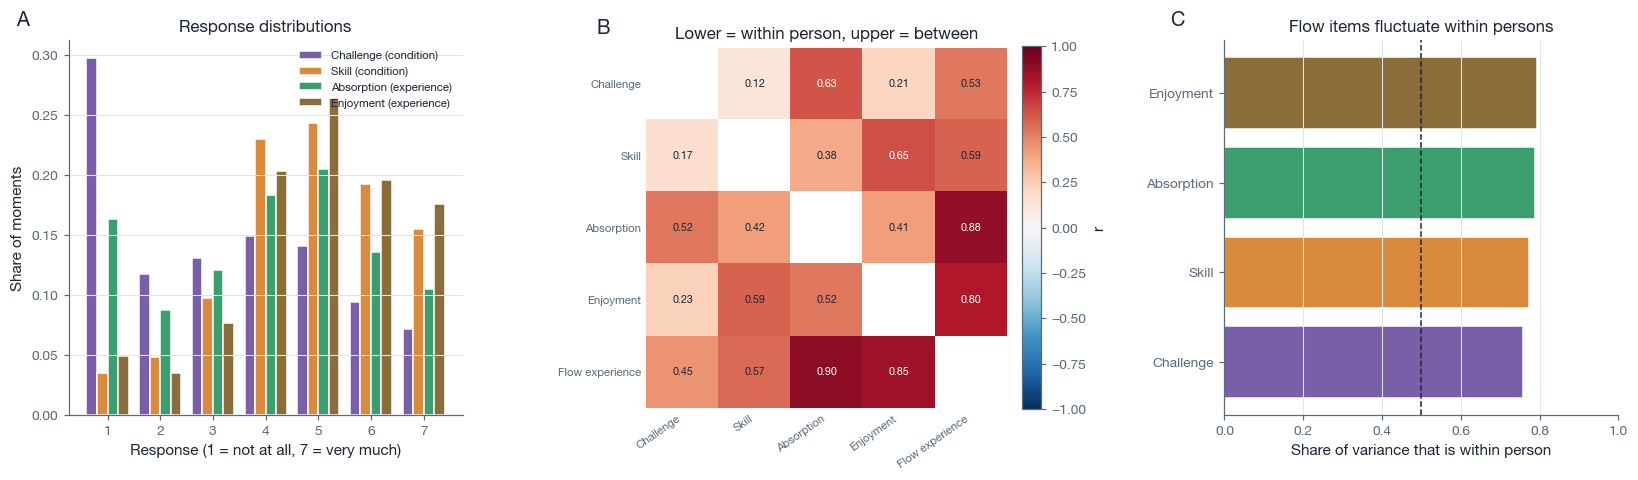

In [13]:
# Figure 1. The instrument: distributions and correlation structure.
fig, ax = plt.subplots(1, 3, figsize=(15, 4.4))

a = ax[0]
w = 0.2
for k, it in enumerate(ITEMS):
    share = f[it].value_counts(normalize=True).reindex(range(1, 8), fill_value=0)
    role = "condition" if it in CONDITION_ITEMS else "experience"
    a.bar(np.arange(1, 8) + (k - 1.5) * w, share.values, w, color=COL[it],
          edgecolor="white", label=f"{LABEL[it]} ({role})")
a.set_xticks(range(1, 8))
a.set_xlabel("Response (1 = not at all, 7 = very much)")
a.set_ylabel("Share of moments")
a.set_title("Response distributions")
a.legend(fontsize=7.5)
bar_axes(a); panel(a, "A")

a = ax[1]
vl = ITEMS + ["FLOWEXP"]
wi = f[[v + "_w" for v in vl]].corr().values
be = f.groupby("pid")[vl].mean().corr().values
M = np.tril(wi, -1) + np.triu(be, 1) + np.diag(np.full(len(vl), np.nan))
im = a.imshow(M, cmap="RdBu_r", vmin=-1, vmax=1)
labs = [LABEL[v] for v in vl]
a.set_xticks(range(len(vl))); a.set_yticks(range(len(vl)))
a.set_xticklabels(labs, rotation=35, ha="right", fontsize=7.5)
a.set_yticklabels(labs, fontsize=7.5)
for i in range(len(vl)):
    for j in range(len(vl)):
        if np.isfinite(M[i, j]):
            a.text(j, i, f"{M[i, j]:.2f}", ha="center", va="center", fontsize=7,
                   color=INK if abs(M[i, j]) < 0.6 else "white")
a.set_title("Lower = within person, upper = between")
matrix_axes(a); fig.colorbar(im, ax=a, fraction=0.046, pad=0.04, label="r")
panel(a, "B")

a = ax[2]
dd = desc[desc["variable"] != "Flow experience"]
a.barh(dd["variable"], dd["within share"], color=[COL[v] for v in ITEMS], edgecolor="white")
a.axvline(0.5, color=INK, ls="--", lw=1.0)
a.set_xlim(0, 1)
a.set_xlabel("Share of variance that is within person")
a.set_title("Flow items fluctuate within persons")
bar_axes(a, horizontal=True); panel(a, "C")

fig.tight_layout(w_pad=2.6)
show(fig, "fig01_instrument")

**Figure 1 in words.** Panel A: challenge is strongly skewed toward the low end, the other three
toward the high end. Panel B: the two condition items are nearly independent of one another
(within-person r = .17), which is what makes the quadrant classification informative rather than
degenerate; the two experience items correlate .52 within person, high enough to justify a
composite and low enough that the enjoyment gate still adds information. Panel C: all four items
are dominated by within-person variance.

---
# 5. V1. Does this population experience flow, and how often?

**Question.** Does a chronic pain sample reach flow at all in daily life, and how frequently?

**Method required by the question.** Absolute level information, so metric A, with the gated index
rather than the bare quadrant. Metrics C and D are reported alongside only to show what they would
have claimed, not as answers.

**Reporting rule.** The per-person distribution must include the zeros. A prevalence figure that
cannot represent absence is not a prevalence figure.

In [14]:
prev_rows = []
per_person_prev = {}
for key, (lab, ch, sk, exp, cut) in RULES.items():
    cond = (f["chan_" + key] == "Flow")
    gated = f["flow_" + key].astype(bool)
    pp = gated.groupby(g).mean()
    per_person_prev[key] = pp
    prev_rows.append({
        "rule": lab,
        "condition met %": round(100 * cond.mean(), 1),
        "gated flow %": round(100 * gated.mean(), 1),
        "gate removes %": round(100 * (cond.mean() - gated.mean()), 1),
        "median person %": round(100 * pp.median(), 1),
        "IQR": f"{100 * pp.quantile(.25):.0f} to {100 * pp.quantile(.75):.0f}",
        "persons at 0": int((pp == 0).sum()),
    })
prev = pd.DataFrame(prev_rows)
display(prev)

,rule,condition met %,gated flow %,gate removes %,median person %,IQR,persons at 0
0,"A. Absolute, both >= 4",39.6,36.8,2.7,35.0,23 to 49,0
1,"A. Absolute, both >= 5",22.0,19.3,2.7,16.4,5 to 27,4
2,B. Grand-mean z,30.6,27.8,2.7,26.7,10 to 36,2
3,C. Within-person z,29.1,24.7,4.4,24.5,17 to 33,0
4,D. Person-mean centred,29.1,24.7,4.4,24.5,17 to 33,0


In [15]:
# Momentary profile of each channel, on the strict absolute rule and on the centred rule.
prof_vars = ["PIJN", "PIJN_AFF", "ATTEND", "THREAT", "FLOWEXP", "NEGAFF", "POSAFF", "ACTIEF"]
prof = []
for key in ["A_abs5", "D_center"]:
    lab = RULES[key][0]
    for ch_name in CHANNELS:
        sel = f["chan_" + key] == ch_name
        row = {"rule": lab, "channel": ch_name, "n": int(sel.sum()),
               "%": round(100 * sel.mean(), 1)}
        for v in prof_vars:
            row[LABEL.get(v, v)] = round(f.loc[sel, v].mean(), 2)
        prof.append(row)
profile = pd.DataFrame(prof)
display(profile)

,rule,channel,n,%,Pain intensity,Pain interference,Attention to pain,Threat value,Flow experience,NEGAFF,POSAFF,ACTIEF
0,"A. Absolute, both >= 5",Flow,1314,22.0,4.90,4.15,2.99,2.34,5.79,1.87,4.43,4.33
1,"A. Absolute, both >= 5",Relaxation,2214,37.0,4.29,3.52,2.69,2.09,4.64,1.79,4.43,2.47
2,"A. Absolute, both >= 5",Anxiety,516,8.6,4.83,4.28,3.11,2.23,4.44,2.06,3.99,4.44
3,"A. Absolute, both >= 5",Apathy,1932,32.3,4.49,3.94,3.00,2.31,3.33,2.05,3.92,2.46
4,D. Person-mean centred,Flow,1737,29.1,4.59,3.89,2.95,2.33,5.45,1.92,4.35,3.99
5,D. Person-mean centred,Relaxation,1597,26.7,4.25,3.53,2.66,2.04,4.54,1.79,4.38,2.21
6,D. Person-mean centred,Anxiety,1082,18.1,4.69,4.11,3.05,2.35,4.35,2.04,4.10,3.99
7,D. Person-mean centred,Apathy,1560,26.1,4.65,3.99,2.95,2.22,3.31,1.96,4.03,2.19


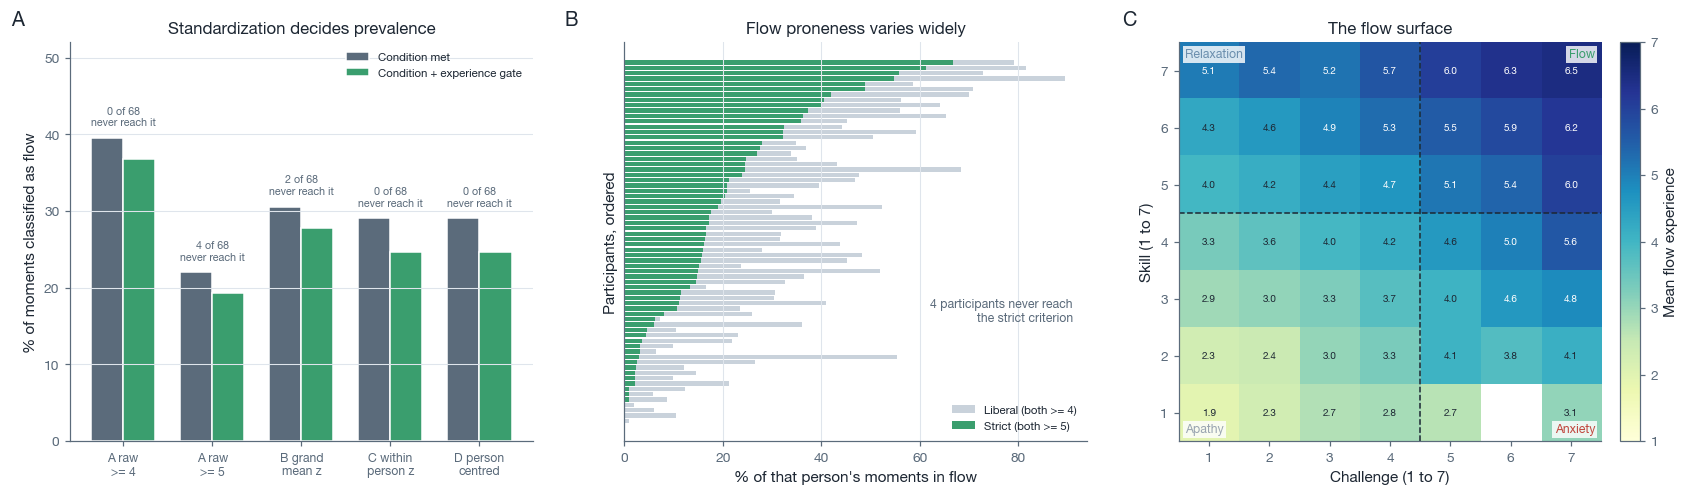

In [16]:
# Figure 2. Prevalence and the flow surface.
fig, ax = plt.subplots(1, 3, figsize=(15.4, 4.6))

a = ax[0]
order = ["A_abs4", "A_abs5", "B_grandz", "C_withinz", "D_center"]
short = {"A_abs4": "A raw\n>= 4", "A_abs5": "A raw\n>= 5", "B_grandz": "B grand\nmean z",
         "C_withinz": "C within\nperson z", "D_center": "D person\ncentred"}
x = np.arange(len(order)); w = 0.36
cond_v = [100 * (f["chan_" + k] == "Flow").mean() for k in order]
gate_v = [100 * f["flow_" + k].mean() for k in order]
a.bar(x - w / 2, cond_v, w, color=MUTED, edgecolor="white", label="Condition met")
a.bar(x + w / 2, gate_v, w, color=CHANNEL_COL["Flow"], edgecolor="white",
      label="Condition + experience gate")
for xi, k in zip(x, order):
    nz = int((per_person_prev[k] == 0).sum())
    a.text(xi, max(cond_v[list(order).index(k)], gate_v[list(order).index(k)]) + 1.6,
           f"{nz} of 68\nnever reach it", ha="center", fontsize=7, color=MUTED)
a.set_xticks(x); a.set_xticklabels([short[k] for k in order], fontsize=8)
a.set_ylim(0, 52); a.set_ylabel("% of moments classified as flow")
a.set_title("Standardization decides prevalence")
a.legend(fontsize=7.5); bar_axes(a); panel(a, "A")

a = ax[1]
pp = per_person_prev["A_abs5"].sort_values()
pp4 = per_person_prev["A_abs4"].reindex(pp.index)
y = np.arange(len(pp))
a.barh(y, 100 * pp4.values, color="#c9d2db", edgecolor="none", label="Liberal (both >= 4)")
a.barh(y, 100 * pp.values, color=CHANNEL_COL["Flow"], edgecolor="none",
       label="Strict (both >= 5)")
a.set_yticks([]); a.set_ylabel("Participants, ordered")
a.set_xlabel("% of that person's moments in flow")
a.set_title("Flow proneness varies widely")
a.text(0.97, 0.30, f"{int((pp == 0).sum())} participants never reach\nthe strict criterion",
       transform=a.transAxes, ha="right", fontsize=8, color=MUTED)
a.legend(fontsize=7.5, loc="lower right"); bar_axes(a, horizontal=True); panel(a, "B")

a = ax[2]
grid = np.full((7, 7), np.nan)
for (c, s), gr in f.groupby(["CHALLENGE", "EFFIC"]):
    if len(gr) >= 10:
        grid[int(s) - 1, int(c) - 1] = gr["FLOWEXP"].mean()
im = a.imshow(grid, origin="lower", cmap="YlGnBu", vmin=1, vmax=7,
              extent=(0.5, 7.5, 0.5, 7.5), aspect="auto")
for si in range(7):
    for ci in range(7):
        if np.isfinite(grid[si, ci]):
            a.text(ci + 1, si + 1, f"{grid[si, ci]:.1f}", ha="center", va="center",
                   fontsize=6.5, color=INK if grid[si, ci] < 4.6 else "white")
a.axvline(4.5, color=INK, lw=1.0, ls="--"); a.axhline(4.5, color=INK, lw=1.0, ls="--")
box = {"facecolor": "white", "alpha": 0.82, "edgecolor": "none", "pad": 1.6}
for fx, fy, ha, va, name in [(0.985, 0.985, "right", "top", "Flow"),
                             (0.985, 0.015, "right", "bottom", "Anxiety"),
                             (0.015, 0.985, "left", "top", "Relaxation"),
                             (0.015, 0.015, "left", "bottom", "Apathy")]:
    a.text(fx, fy, name, transform=a.transAxes, fontsize=8, ha=ha, va=va,
           color=CHANNEL_COL[name], bbox=box, zorder=5,
           fontweight="bold" if name == "Flow" else "normal")
a.set_xticks(range(1, 8)); a.set_yticks(range(1, 8))
a.set_xlabel("Challenge (1 to 7)"); a.set_ylabel("Skill (1 to 7)")
a.set_title("The flow surface")
a.grid(False); fig.colorbar(im, ax=a, fraction=0.046, pad=0.04, label="Mean flow experience")
panel(a, "C")

fig.tight_layout(w_pad=2.6)
show(fig, "fig02_prevalence")

## Answer to V1

**Yes, and often, but the number depends entirely on the criterion, and that dependence is itself
the finding.**

Under the conservative absolute criterion (both condition items at 5 or above, plus a flow
experience of 5 or above), **19.3 percent of moments qualify as flow**, the median participant
reaches it in 16.4 percent of their moments, and **four of 68 participants never reach it at all**.
Under the liberal absolute criterion (both at 4 or above) the figure roughly doubles to 36.8
percent and nobody is at zero.

Under the relative metrics (B, C, D) between 24.7 and 27.8 percent of moments are flow, and at
most two participants are at zero. As anticipated in section 3, the relative metrics cannot
represent absence.

Two substantive points beyond the headline number.

**The experience gate does real work but not much.** Requiring the moment to be experienced as
absorbing and enjoyable, not merely structurally balanced, removes 2.7 to 4.4 percentage points,
between one in eight and one in seven candidate moments. The gate is worth keeping because it is the conceptual
safeguard against "balanced but disengaged", but it is not doing the heavy lifting.

**The sample sits in the relaxation corner, not the flow corner.** Under the strict rule the
largest channel is relaxation (37.0 percent, low challenge and high skill), not flow (22.0 percent
before gating). Panel C shows why: the modal moment has low challenge and moderate to high skill.
This population spends most of its diary time doing familiar, undemanding things it is good at.
That is a clinically sensible picture of daily life with chronic pain, and it shapes everything
that follows.

---
# 6. V2. Does the flow model behave as theory predicts?

**Question.** Does the challenge-skill configuration predict the flow experience, as the theory
says it should?

**Method required by the question.** Within-person variation, metric D, condition option 2
(balance and elevation), and analysis track B (hybrid multilevel with random slopes). Track B is
chosen over track A (random intercepts only) because a fixed average would mask exactly the
person heterogeneity this project is about, and over track C (fully per person) because partial
pooling stabilises the shorter series while still quantifying the spread.

**Specification.**

```
FLOWEXP ~ balance_w + elevation_w + balance_b + elevation_b + (1 + balance_w + elevation_w | pid)
```

The within terms carry the momentary flow model. The between terms absorb stable person
differences in challenge and skill so the within estimates are not contaminated by them, which is
the standard within-between decomposition.

In [17]:
m_v2 = mixed("FLOWEXP ~ balance_w + elevation_w + balance_b + elevation_b", f,
             re_formula="~balance_w + elevation_w")

res_v2 = tidy(m_v2, keep=["balance_w", "elevation_w", "balance_b", "elevation_b"])
res_v2["term"] = ["Balance (within)", "Elevation (within)",
                  "Balance (between)", "Elevation (between)"]
res_v2["random SD"] = [round(random_sd(m_v2, "balance_w"), 3),
                       round(random_sd(m_v2, "elevation_w"), 3), "", ""]
print(f"n = {m_v2._n_obs:,} moments in {m_v2._n_grp} persons")
display(res_v2)

# Variance explained by the within terms, as a marginal R2 on the centred outcome.
r2 = np.corrcoef(f.dropna(subset=["FLOWEXP_w", "balance_w", "elevation_w"])["FLOWEXP_w"],
                 np.polyval(np.polyfit(
                     f.dropna(subset=["FLOWEXP_w", "elevation_w"])["elevation_w"],
                     f.dropna(subset=["FLOWEXP_w", "elevation_w"])["FLOWEXP_w"], 1),
                     f.dropna(subset=["FLOWEXP_w", "elevation_w"])["elevation_w"]))[0, 1] ** 2
print(f"\nwithin-person variance in the flow experience explained by elevation alone: R2 = {r2:.3f}")

n = 5,976 moments in 68 persons


,term,b,SE,z,p,random SD
0,Balance (within),0.005,0.020,0.24,.809,0.132
1,Elevation (within),0.744,0.024,31.53,<.001,0.164
2,Balance (between),-0.108,0.051,-2.13,.033,
3,Elevation (between),0.804,0.085,9.44,<.001,



within-person variance in the flow experience explained by elevation alone: R2 = 0.425


### Alternative parameterizations

Before interpreting, the primary specification is compared against the two obvious alternatives:
the additive form with an interaction (challenge and skill as separate main effects plus their
product) and the categorical quadrant. If a simpler or a different form fits better, that is
substantive information about how the condition actually works.

In [18]:
m_int = mixed("FLOWEXP ~ CHALLENGE_w * EFFIC_w + CHALLENGE_b + EFFIC_b", f,
              re_formula="~CHALLENGE_w + EFFIC_w")
f["chan_D_ref"] = f["chan_D_center"].cat.reorder_categories(
    ["Apathy", "Flow", "Relaxation", "Anxiety"])
m_quad = mixed("FLOWEXP ~ C(chan_D_ref)", f, re_formula=None)

display(tidy(m_int, keep=["CHALLENGE_w", "EFFIC_w", "CHALLENGE_w:EFFIC_w",
                          "CHALLENGE_b", "EFFIC_b"], label="challenge x skill"))

qt = tidy(m_quad, label="quadrant (vs apathy)")
qt["term"] = qt["term"].str.replace(r"C\(chan_D_ref\)\[T\.|\]", "", regex=True)
display(qt)


def ic(fit):
    '''AIC and BIC from a REML=False refit, so the comparison is on the same likelihood.'''
    return fit.aic, fit.bic


cmp_rows = []
for lab, formula, re_f in [
        ("balance + elevation",
         "FLOWEXP ~ balance_w + elevation_w + balance_b + elevation_b",
         "~balance_w + elevation_w"),
        ("challenge x skill (additive + interaction)",
         "FLOWEXP ~ CHALLENGE_w * EFFIC_w + CHALLENGE_b + EFFIC_b",
         "~CHALLENGE_w + EFFIC_w"),
        ("quadrant (categorical)", "FLOWEXP ~ C(chan_D_ref)", None)]:
    fit = mixed(formula, f, re_formula=re_f, reml=False)
    a, b = ic(fit)
    cmp_rows.append({"model": lab, "AIC": round(a, 1), "BIC": round(b, 1),
                     "n": fit._n_obs})
cmp = pd.DataFrame(cmp_rows).sort_values("AIC").reset_index(drop=True)
display(cmp)

,model,term,b,SE,z,p
0,challenge x skill,CHALLENGE_w,0.296,0.018,16.10,<.001
1,challenge x skill,EFFIC_w,0.486,0.020,24.19,<.001
2,challenge x skill,CHALLENGE_w:EFFIC_w,-0.007,0.005,-1.44,.149
3,challenge x skill,CHALLENGE_b,0.339,0.057,5.97,<.001
4,challenge x skill,EFFIC_b,0.485,0.075,6.43,<.001


,model,term,b,SE,z,p
0,quadrant (vs apathy),Intercept,3.336,0.083,40.08,<.001
1,quadrant (vs apathy),Flow,2.115,0.040,53.05,<.001
2,quadrant (vs apathy),Relaxation,1.257,0.041,30.58,<.001
3,quadrant (vs apathy),Anxiety,0.957,0.045,21.15,<.001


,model,AIC,BIC,n
0,challenge x skill (additive + interaction),16879.3,16966.3,5976
1,balance + elevation,17319.6,17399.9,5976
2,quadrant (categorical),18487.4,18527.6,5976


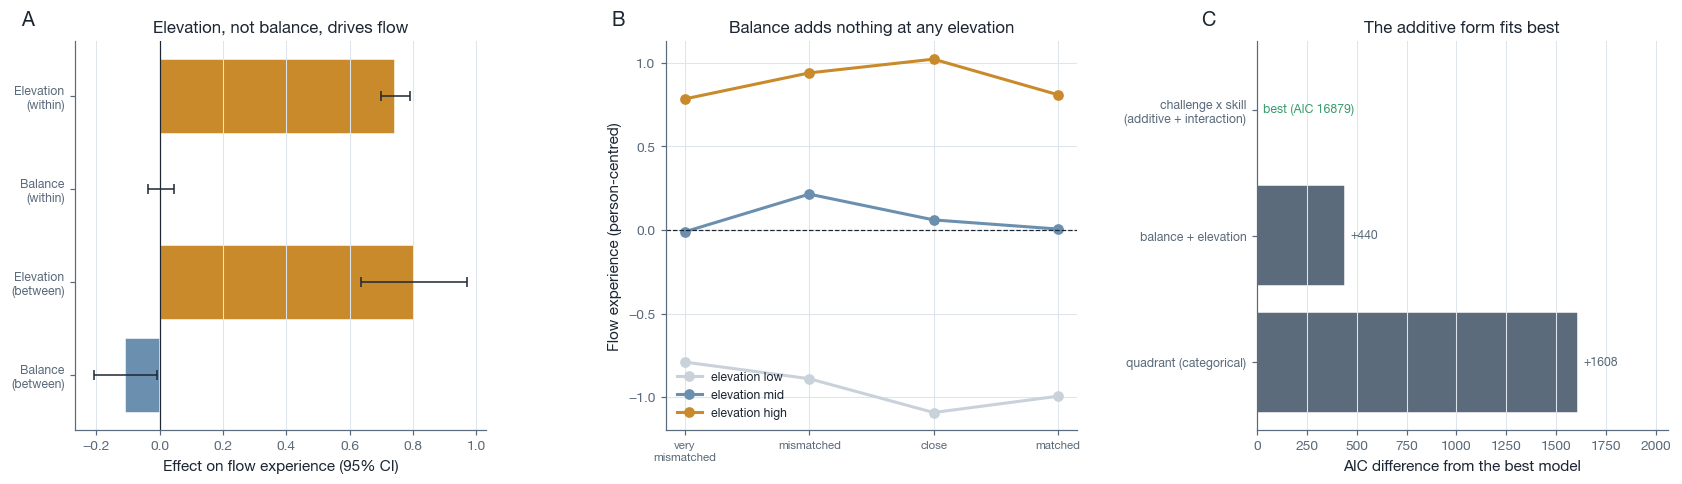

In [19]:
# Figure 3. The condition-to-experience model.
fig, ax = plt.subplots(1, 3, figsize=(15.4, 4.5))

a = ax[0]
terms = ["elevation_w", "balance_w", "elevation_b", "balance_b"]
labs = ["Elevation\n(within)", "Balance\n(within)", "Elevation\n(between)", "Balance\n(between)"]
vals = [m_v2.params[t] for t in terms]
ses = [m_v2.bse[t] for t in terms]
cols = [COL["elevation"], COL["balance"]] * 2
y = np.arange(len(terms))[::-1]
a.barh(y, vals, xerr=1.96 * np.array(ses), color=cols, edgecolor="white",
       error_kw={"ecolor": INK, "elinewidth": 1.0, "capsize": 3})
a.axvline(0, color=INK, lw=0.8)
a.set_yticks(y); a.set_yticklabels(labs, fontsize=8)
a.set_xlabel("Effect on flow experience (95% CI)")
a.set_title("Elevation, not balance, drives flow")
bar_axes(a, horizontal=True); panel(a, "A")

a = ax[1]
# Observed flow experience along the balance axis at three levels of elevation.
d3 = f.dropna(subset=["balance_w", "elevation_w", "FLOWEXP_w"]).copy()
d3["elev_bin"] = pd.qcut(d3["elevation_w"], 3, labels=["low", "mid", "high"])
d3["bal_bin"] = pd.cut(d3["balance_w"], bins=[-6.5, -2.5, -1.5, -0.5, 0.5],
                       labels=["very\nmismatched", "mismatched", "close", "matched"])
for lab_e, colr in zip(["low", "mid", "high"], ["#c9d2db", COL["balance"], COL["elevation"]]):
    sub = d3[d3["elev_bin"] == lab_e].groupby("bal_bin", observed=True)["FLOWEXP_w"].mean()
    a.plot(range(len(sub)), sub.values, "o-", color=colr, lw=2, ms=6,
           label=f"elevation {lab_e}")
a.set_xticks(range(4))
a.set_xticklabels(["very\nmismatched", "mismatched", "close", "matched"], fontsize=7.5)
a.axhline(0, color=INK, lw=0.8, ls="--")
a.set_ylabel("Flow experience (person-centred)")
a.set_title("Balance adds nothing at any elevation")
a.legend(fontsize=8); panel(a, "B")

a = ax[2]
cc = cmp.sort_values("AIC", ascending=False)
delta = (cc["AIC"] - cc["AIC"].min()).values
a.barh(range(len(cc)), delta,
       color=[CHANNEL_COL["Flow"] if i == len(cc) - 1 else MUTED for i in range(len(cc))],
       edgecolor="white")
for i, (dv, aic) in enumerate(zip(delta, cc["AIC"])):
    txt = f"best (AIC {aic:.0f})" if dv == 0 else f"+{dv:.0f}"
    a.text(dv + 30, i, txt, va="center", fontsize=8,
           color=CHANNEL_COL["Flow"] if dv == 0 else MUTED,
           fontweight="bold" if dv == 0 else "normal")
a.set_xlim(0, delta.max() * 1.28)
a.set_yticks(range(len(cc)))
a.set_yticklabels([m.replace(" (additive + interaction)", "\n(additive + interaction)")
                   for m in cc["model"]], fontsize=8)
a.set_xlabel("AIC difference from the best model")
a.set_title("The additive form fits best")
bar_axes(a, horizontal=True); panel(a, "C")

fig.tight_layout(w_pad=2.8)
show(fig, "fig03_condition_experience")

## Answer to V2

**The flow model holds in one half and fails in the other, and the failure is not a null but a
reversal.**

**What works.** Elevation is a very strong predictor of the flow experience within persons
(b = 0.744, SE = 0.024, p < .001). A moment in which challenge and skill are both above the
person's own average is substantially more absorbing and enjoyable. On its own, elevation accounts
for roughly 43 percent of the within-person variance in the flow experience. There is real and
meaningful heterogeneity in that slope across persons (random SD = 0.16).

**What fails.** Within-person balance is exactly null (b = 0.005, SE = 0.020, p = .81). Panel B of
figure 3 shows why the null is not a power problem: at every level of elevation the flow
experience is flat across the whole range from very mismatched to perfectly matched. Between
persons the balance effect is significantly **negative** (b = -0.108, SE = 0.051, p = .033), and
section 10.1 shows the same reversal on the raw absolute scale (b = -0.090, p < .001).

**How to read the between-person reversal.** People whose challenge and skill ratings are on
average better matched report a *lower* average flow experience. The most plausible reading in
this population: chronically matched challenge and skill indexes a narrow, low-demand activity
repertoire, someone who only ever does the easy things they are good at, rather than a person
living in the optimal-challenge zone. This is a between-person description of an activity pattern,
not a within-person mechanism, and it should be presented as such.

**Which parameterization the data prefer.** The additive form, challenge and skill as separate
main effects, fits substantially better than the balance-and-elevation form (AIC 16879 versus
17320), and the challenge-by-skill interaction inside it is not significant (b = -0.007, p = .15).
The categorical quadrant fits worst by a wide margin, which is the expected cost of throwing away
continuous information.

**The methodological conclusion.** In this dataset the flow condition acts **additively**, not
configurationally. More challenge helps, more skill helps roughly twice as much (b = 0.30 versus
0.49), and their matching is irrelevant. That is a genuine, reportable, partly negative result
about the flow model, consistent in direction with the meta-analytic finding that the pure balance
effect is weak once elevation is accounted for (Fong et al., 2015) and stronger than it.

---
# 7. V3. Temporal structure and person specificity

**Question, in two parts.** Does the challenge-skill configuration *precede* the flow experience
in time, and does the flow relation differ from person to person?

**Method.** Lags are built within day, on person-standardized scores, so no lag crosses the
overnight gap and the coefficients are on the same metric as the study's other lagged analyses.
Roughly 90 minutes separate consecutive beeps. Two analysis levels: a multilevel lagged model
(track B) for the average temporal effect, and per-person regressions (track C) for the
distribution.

In [20]:
# Within-day lag-1 construction on person-standardized scores.
z = f.sort_values(["pid", "day", "beep"]).copy()
LAGVARS = ["FLOWEXP", "CHALLENGE", "EFFIC", "PIJN", "ATTEND", "PIJN_AFF", "THREAT"]
for v in LAGVARS:
    z[v + "_zz"] = within_z(z[v], z["pid"])
z["balance_zz"] = -(z["CHALLENGE_zz"] - z["EFFIC_zz"]).abs()
z["elevation_zz"] = (z["CHALLENGE_zz"] + z["EFFIC_zz"]) / 2

daykey = z["pid"].astype(str) + "_" + z["day"].astype(str)
for v in [c + "_zz" for c in LAGVARS] + ["balance_zz", "elevation_zz"]:
    z[v + "_lag"] = z.groupby(daykey)[v].shift(1)

print(f"lagged frame: {z['FLOWEXP_zz_lag'].notna().sum():,} usable lag-1 pairs "
      f"({z.loc[z['FLOWEXP_zz_lag'].notna(), 'pid'].nunique()} persons)")

lagged frame: 5,065 usable lag-1 pairs (68 persons)


In [21]:
# 7.1 Does the condition at t-1 predict the experience at t?
m_v3 = mixed("FLOWEXP_zz ~ balance_zz_lag + elevation_zz_lag + FLOWEXP_zz_lag", z,
             re_formula="~balance_zz_lag + elevation_zz_lag")
t_v3 = tidy(m_v3, keep=["balance_zz_lag", "elevation_zz_lag", "FLOWEXP_zz_lag"])
t_v3["term"] = ["Balance (t-1)", "Elevation (t-1)", "Flow experience (t-1), autoregression"]
print(f"n = {m_v3._n_obs:,} lag-1 pairs in {m_v3._n_grp} persons")
display(t_v3)

# Same-beep reference on the identical rows, to size the lagged effect against the concurrent one.
m_same = mixed("FLOWEXP_zz ~ balance_zz + elevation_zz",
               z[z["FLOWEXP_zz_lag"].notna()], re_formula="~balance_zz + elevation_zz")
ts = tidy(m_same, keep=["balance_zz", "elevation_zz"])
ts["term"] = ["Balance (same beep)", "Elevation (same beep)"]
display(ts)
print(f"lagged elevation is {100 * m_v3.params['elevation_zz_lag'] / m_same.params['elevation_zz']:.0f}% "
      f"of the concurrent elevation effect")

n = 5,065 lag-1 pairs in 68 persons


,term,b,SE,z,p
0,Balance (t-1),-0.009,0.022,-0.42,.677
1,Elevation (t-1),0.051,0.025,2.06,.039
2,"Flow experience (t-1), autoregression",0.108,0.019,5.75,<.001


,term,b,SE,z,p
0,Balance (same beep),0.000,0.021,0.02,.986
1,Elevation (same beep),0.854,0.022,38.51,<.001


lagged elevation is 6% of the concurrent elevation effect


### Reading the lagged condition-to-experience result

There **is** a temporal signature inside the flow model, and it is small.

Elevation at the previous beep predicts the flow experience at the current beep (b = 0.051,
SE = 0.025, p = .039), over and above the flow experience's own autoregression (b = 0.108). Balance
at the previous beep does not (b = -0.009, p = .68), which is consistent with its concurrent null.

The size is the point. The lagged elevation effect is about **6 percent** of the concurrent one
(0.051 against 0.854). So a demanding, masterful moment leaves a faint absorption residue roughly
90 minutes later, but the flow model is overwhelmingly a same-moment phenomenon. The temporal
antecedence that the theory implies is technically detectable and practically negligible at this
sampling interval.

In [22]:
# 7.2 Person-specific flow-pain associations.
MIN_IDIO = 50
per_rows = []
for pid, gr in z.groupby("pid"):
    gc = gr.dropna(subset=["FLOWEXP_zz", "PIJN_zz"])
    if len(gc) < MIN_IDIO:
        continue
    # Estimated on person-standardized scores, so the concurrent slope is on the same
    # metric as the lagged slope below and the two are directly comparable.
    r = np.corrcoef(gc["FLOWEXP"], gc["PIJN"])[0, 1]
    fit = smf.ols("PIJN_zz ~ FLOWEXP_zz", gc).fit()
    ci = fit.conf_int().loc["FLOWEXP_zz"]
    row = {"pid": pid, "n": len(gc), "r": round(r, 3),
           "b_concurrent": round(fit.params["FLOWEXP_zz"], 3),
           "lo": round(ci[0], 3), "hi": round(ci[1], 3),
           "p": fit.pvalues["FLOWEXP_zz"]}
    gl = gr.dropna(subset=["PIJN_zz", "FLOWEXP_zz_lag", "PIJN_zz_lag"])
    if len(gl) >= 25:
        fl = smf.ols("PIJN_zz ~ FLOWEXP_zz_lag + PIJN_zz_lag", gl).fit()
        cl = fl.conf_int().loc["FLOWEXP_zz_lag"]
        row.update({"b_lagged": round(fl.params["FLOWEXP_zz_lag"], 3),
                    "lo_lag": round(cl[0], 3), "hi_lag": round(cl[1], 3)})
    per_rows.append(row)
per = pd.DataFrame(per_rows).sort_values("b_concurrent").reset_index(drop=True)

summary = pd.DataFrame([
    {"quantity": "concurrent slope", "n persons": per["b_concurrent"].notna().sum(),
     "median": round(per["b_concurrent"].median(), 3),
     "IQR": f"{per['b_concurrent'].quantile(.25):.3f} to {per['b_concurrent'].quantile(.75):.3f}",
     "range": f"{per['b_concurrent'].min():.3f} to {per['b_concurrent'].max():.3f}",
     "% negative": round(100 * (per["b_concurrent"] < 0).mean(), 1),
     "reliably negative": int((per["hi"] < 0).sum()),
     "reliably positive": int((per["lo"] > 0).sum())},
    {"quantity": "lagged slope", "n persons": per["b_lagged"].notna().sum(),
     "median": round(per["b_lagged"].median(), 3),
     "IQR": f"{per['b_lagged'].quantile(.25):.3f} to {per['b_lagged'].quantile(.75):.3f}",
     "range": f"{per['b_lagged'].min():.3f} to {per['b_lagged'].max():.3f}",
     "% negative": round(100 * (per["b_lagged"] < 0).mean(), 1),
     "reliably negative": int((per["hi_lag"] < 0).sum()),
     "reliably positive": int((per["lo_lag"] > 0).sum())},
])
display(summary)

,quantity,n persons,median,IQR,range,% negative,reliably negative,reliably positive
0,concurrent slope,63,-0.137,-0.203 to 0.010,-0.465 to 0.445,73.0,14,4
1,lagged slope,63,-0.000,-0.084 to 0.052,-0.265 to 0.227,49.2,2,0


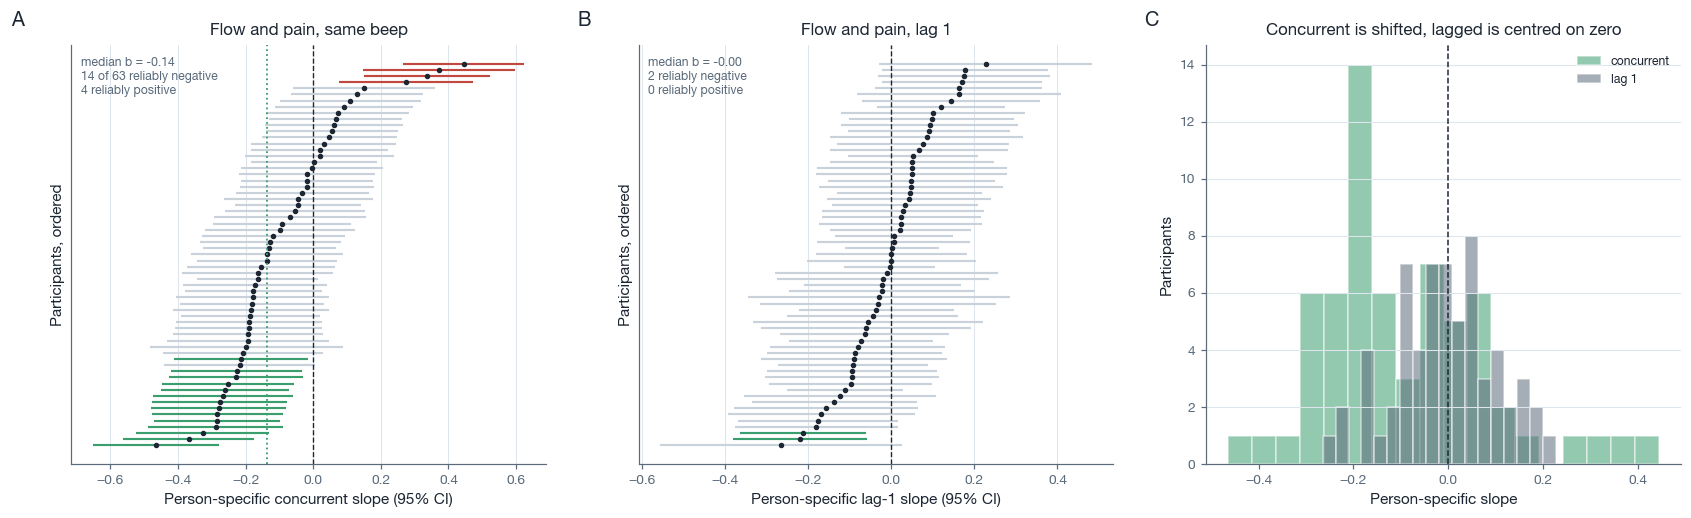

In [23]:
# Figure 4. Person specificity.
fig, ax = plt.subplots(1, 3, figsize=(15.4, 4.8))

a = ax[0]
pp = per.dropna(subset=["b_concurrent"]).reset_index(drop=True)
y = np.arange(len(pp))
sig_neg, sig_pos = pp["hi"] < 0, pp["lo"] > 0
cols = np.where(sig_neg, CHANNEL_COL["Flow"], np.where(sig_pos, COL["PIJN"], "#c9d2db"))
a.hlines(y, pp["lo"], pp["hi"], color=cols, lw=1.4)
a.plot(pp["b_concurrent"], y, "o", ms=2.6, color=INK)
a.axvline(0, color=INK, lw=0.9, ls="--")
a.axvline(pp["b_concurrent"].median(), color=CHANNEL_COL["Flow"], lw=1.2, ls=":")
a.text(0.02, 0.97, f"median b = {pp['b_concurrent'].median():.2f}\n"
       f"{int(sig_neg.sum())} of {len(pp)} reliably negative\n"
       f"{int(sig_pos.sum())} reliably positive",
       transform=a.transAxes, va="top", fontsize=8, color=MUTED)
a.set_yticks([]); a.set_ylabel("Participants, ordered")
a.set_xlabel("Person-specific concurrent slope (95% CI)")
a.set_title("Flow and pain, same beep")
panel(a, "A")

a = ax[1]
pl = per.dropna(subset=["b_lagged"]).sort_values("b_lagged").reset_index(drop=True)
y = np.arange(len(pl))
sn, sp = pl["hi_lag"] < 0, pl["lo_lag"] > 0
cols = np.where(sn, CHANNEL_COL["Flow"], np.where(sp, COL["PIJN"], "#c9d2db"))
a.hlines(y, pl["lo_lag"], pl["hi_lag"], color=cols, lw=1.4)
a.plot(pl["b_lagged"], y, "o", ms=2.6, color=INK)
a.axvline(0, color=INK, lw=0.9, ls="--")
a.text(0.02, 0.97, f"median b = {pl['b_lagged'].median():.2f}\n"
       f"{int(sn.sum())} reliably negative\n{int(sp.sum())} reliably positive",
       transform=a.transAxes, va="top", fontsize=8, color=MUTED)
a.set_yticks([]); a.set_ylabel("Participants, ordered")
a.set_xlabel("Person-specific lag-1 slope (95% CI)")
a.set_title("Flow and pain, lag 1")
panel(a, "B")

a = ax[2]
a.hist(pp["b_concurrent"], bins=18, color=CHANNEL_COL["Flow"], alpha=0.55,
       edgecolor="white", label="concurrent")
a.hist(pl["b_lagged"], bins=18, color=MUTED, alpha=0.55, edgecolor="white", label="lag 1")
a.axvline(0, color=INK, lw=1.0, ls="--")
a.set_xlabel("Person-specific slope"); a.set_ylabel("Participants")
a.set_title("Concurrent is shifted, lagged is centred on zero")
a.legend(fontsize=8); bar_axes(a); panel(a, "C")

fig.tight_layout(w_pad=2.6)
show(fig, "fig04_person_specificity")

## Answer to V3

**Temporal structure: essentially absent between flow and pain, faintly present inside the flow
model.** Elevation at t-1 predicts absorption at t at about 6 percent of the concurrent effect
size. Flow at t-1 predicts nothing about pain at t, in either direction (section 8.2).

**Person specificity: substantial and the most clinically interesting result in this notebook.**

The concurrent flow-pain slope, on person-standardized scores so that it is directly comparable
with the lagged slope, has a median of -0.137, an interquartile range from -0.203 to +0.010, and a
range from -0.465 to +0.445. **73 percent of participants show
the negative pattern**, 14 of 63 with a confidence interval entirely below zero, and **4 with a
confidence interval entirely above zero**. For those four, more absorption reliably accompanies
more pain.

The lagged distribution is a striking contrast. Its median is 0.000, 49.2 percent of
persons are negative, and only 2 of 63 reach reliability in either direction, which is
approximately what one expects by chance at 5 percent. Panel C makes the comparison visually
unambiguous: the concurrent distribution is displaced to the left of zero, the lagged distribution
sits on top of it.

**Interpretation.** Activity engagement is a defensible default target in daily-life pain
management, but not a universal one, and which kind of person someone is can be established from a
two-week diary. That is a concrete, checkable, individual-level claim, and it reinforces the
idiographic argument the wider study makes.

---
# 8. Flow and the momentary experience of pain

This section goes beyond the operationalization question. Its motivation is theoretical: the
interruptive-function model (Eccleston and Crombez, 1999) holds that pain captures attention away
from goal pursuit, while flow describes the state in which goal pursuit absorbs attention so
completely that competing signals fail to intrude. Flow is, in that sense, the mirror image of
pain interruption. A recent review (Gromakovskis and Gutmanis, 2025) proposes "flow-induced
analgesia" as a mechanism and notes explicitly that it has never been examined in daily life.

Four outcomes are modelled: pain intensity, pain interference, attention to pain, and threat
value. Each in an unadjusted and an activity-adjusted version, because challenge co-occurs
strongly with being physically active (within-person r = .57) and activity independently raises
pain in this population.

In [24]:
# 8.1 Concurrent models.
OUTCOMES = ["PIJN", "PIJN_AFF", "ATTEND", "THREAT"]
con_rows, rand_rows = [], []
for o in OUTCOMES:
    m1 = mixed(f"{o} ~ FLOWEXP_w + balance_w + elevation_w", f, re_formula="~FLOWEXP_w")
    m2 = mixed(f"{o} ~ FLOWEXP_w + balance_w + elevation_w + ACTIEF_w", f,
               re_formula="~FLOWEXP_w")
    for lab, m in [("unadjusted", m1), ("activity-adjusted", m2)]:
        con_rows.append({"outcome": LABEL[o], "model": lab,
                         "b": round(m.params["FLOWEXP_w"], 3),
                         "SE": round(m.bse["FLOWEXP_w"], 3),
                         "z": round(m.tvalues["FLOWEXP_w"], 2),
                         "p": fmt_p(m.pvalues["FLOWEXP_w"]),
                         "n": m._n_obs})
    rand_rows.append({"outcome": LABEL[o],
                      "fixed b": round(m2.params["FLOWEXP_w"], 3),
                      "random SD": round(random_sd(m2, "FLOWEXP_w"), 3)})
concurrent = pd.DataFrame(con_rows)
display(concurrent)
print("\nHeterogeneity of the flow effect across persons (activity-adjusted models):")
display(pd.DataFrame(rand_rows))

,outcome,model,b,SE,z,p,n
0,Pain intensity,unadjusted,-0.096,0.020,-4.83,<.001,5976
1,Pain intensity,activity-adjusted,-0.094,0.020,-4.69,<.001,5969
2,Pain interference,unadjusted,-0.143,0.025,-5.78,<.001,5938
3,Pain interference,activity-adjusted,-0.139,0.025,-5.56,<.001,5931
4,Attention to pain,unadjusted,-0.077,0.019,-4.13,<.001,5948
5,Attention to pain,activity-adjusted,-0.074,0.019,-3.95,<.001,5941
6,Threat value,unadjusted,-0.080,0.014,-5.80,<.001,5954
7,Threat value,activity-adjusted,-0.079,0.014,-5.68,<.001,5947



Heterogeneity of the flow effect across persons (activity-adjusted models):


,outcome,fixed b,random SD
0,Pain intensity,-0.094,0.123
1,Pain interference,-0.139,0.190
2,Attention to pain,-0.074,0.105
3,Threat value,-0.079,0.058


In [25]:
# Are the condition terms doing anything once the experience is in the model?
m_full = mixed("PIJN ~ FLOWEXP_w + balance_w + elevation_w + ACTIEF_w", f,
               re_formula="~FLOWEXP_w")
t = tidy(m_full, keep=["FLOWEXP_w", "balance_w", "elevation_w", "ACTIEF_w"])
t["term"] = ["Flow experience", "Balance", "Elevation", "Physical activation"]
display(t)

,term,b,SE,z,p
0,Flow experience,-0.094,0.020,-4.69,<.001
1,Balance,-0.024,0.012,-1.94,.052
2,Elevation,-0.003,0.018,-0.15,.883
3,Physical activation,0.019,0.010,1.97,.048


In [26]:
# 8.2 Lag-1 models, both directions.
lag_rows = []
for o in OUTCOMES:
    m = mixed(f"{o}_zz ~ FLOWEXP_zz_lag + {o}_zz_lag", z, re_formula="~FLOWEXP_zz_lag")
    lag_rows.append({"direction": "flow (t-1) -> outcome (t)", "outcome": LABEL[o],
                     "b": round(m.params["FLOWEXP_zz_lag"], 3),
                     "SE": round(m.bse["FLOWEXP_zz_lag"], 3),
                     "p": fmt_p(m.pvalues["FLOWEXP_zz_lag"]),
                     "autoregression": round(m.params[f"{o}_zz_lag"], 3),
                     "n": m._n_obs})
for p_ in ["PIJN", "ATTEND", "THREAT"]:
    m = mixed(f"FLOWEXP_zz ~ {p_}_zz_lag + FLOWEXP_zz_lag", z, re_formula=f"~{p_}_zz_lag")
    lag_rows.append({"direction": "predictor (t-1) -> flow (t)", "outcome": LABEL[p_],
                     "b": round(m.params[f"{p_}_zz_lag"], 3),
                     "SE": round(m.bse[f"{p_}_zz_lag"], 3),
                     "p": fmt_p(m.pvalues[f"{p_}_zz_lag"]),
                     "autoregression": round(m.params["FLOWEXP_zz_lag"], 3),
                     "n": m._n_obs})
lagged = pd.DataFrame(lag_rows)
display(lagged)

,direction,outcome,b,SE,p,autoregression,n
0,flow (t-1) -> outcome (t),Pain intensity,0.002,0.031,.952,0.399,5065
1,flow (t-1) -> outcome (t),Pain interference,0.005,0.033,.873,0.352,4999
2,flow (t-1) -> outcome (t),Attention to pain,-0.011,0.034,.737,0.266,5016
3,flow (t-1) -> outcome (t),Threat value,-0.009,0.033,.787,0.322,5025
4,predictor (t-1) -> flow (t),Pain intensity,-0.018,0.034,.598,0.123,5065
5,predictor (t-1) -> flow (t),Attention to pain,-0.002,0.035,.955,0.128,5039
6,predictor (t-1) -> flow (t),Threat value,-0.018,0.035,.613,0.127,5044


In [27]:
# 8.3 Channel contrasts: which channel is least painful?
f["chan_ref"] = f["chan_D_center"].cat.reorder_categories(
    ["Apathy", "Flow", "Relaxation", "Anxiety"])
chan_rows = []
for o in OUTCOMES:
    m = mixed(f"{o} ~ C(chan_ref)", f)
    for term in m.params.index:
        if "chan_ref" not in term:
            continue
        name = term.split("T.")[1].rstrip("]")
        chan_rows.append({"outcome": LABEL[o], "channel (vs apathy)": name,
                          "b": round(m.params[term], 3),
                          "SE": round(m.bse[term], 3),
                          "p": fmt_p(m.pvalues[term])})
channel_contrasts = pd.DataFrame(chan_rows)
display(channel_contrasts.pivot(index="channel (vs apathy)", columns="outcome",
                                values="b").reindex(["Flow", "Relaxation", "Anxiety"]))
display(channel_contrasts)

outcome,Attention to pain,Pain intensity,Pain interference,Threat value
channel (vs apathy),,,,
Flow,-0.170,-0.179,-0.168,-0.074
Relaxation,-0.281,-0.215,-0.280,-0.169
Anxiety,-0.009,0.028,0.125,0.043


,outcome,channel (vs apathy),b,SE,p
0,Pain intensity,Flow,-0.179,0.039,<.001
1,Pain intensity,Relaxation,-0.215,0.040,<.001
2,Pain intensity,Anxiety,0.028,0.044,.531
3,Pain interference,Flow,-0.168,0.047,<.001
4,Pain interference,Relaxation,-0.280,0.049,<.001
5,Pain interference,Anxiety,0.125,0.054,.020
6,Attention to pain,Flow,-0.170,0.039,<.001
7,Attention to pain,Relaxation,-0.281,0.040,<.001
8,Attention to pain,Anxiety,-0.009,0.044,.837
9,Threat value,Flow,-0.074,0.030,.013


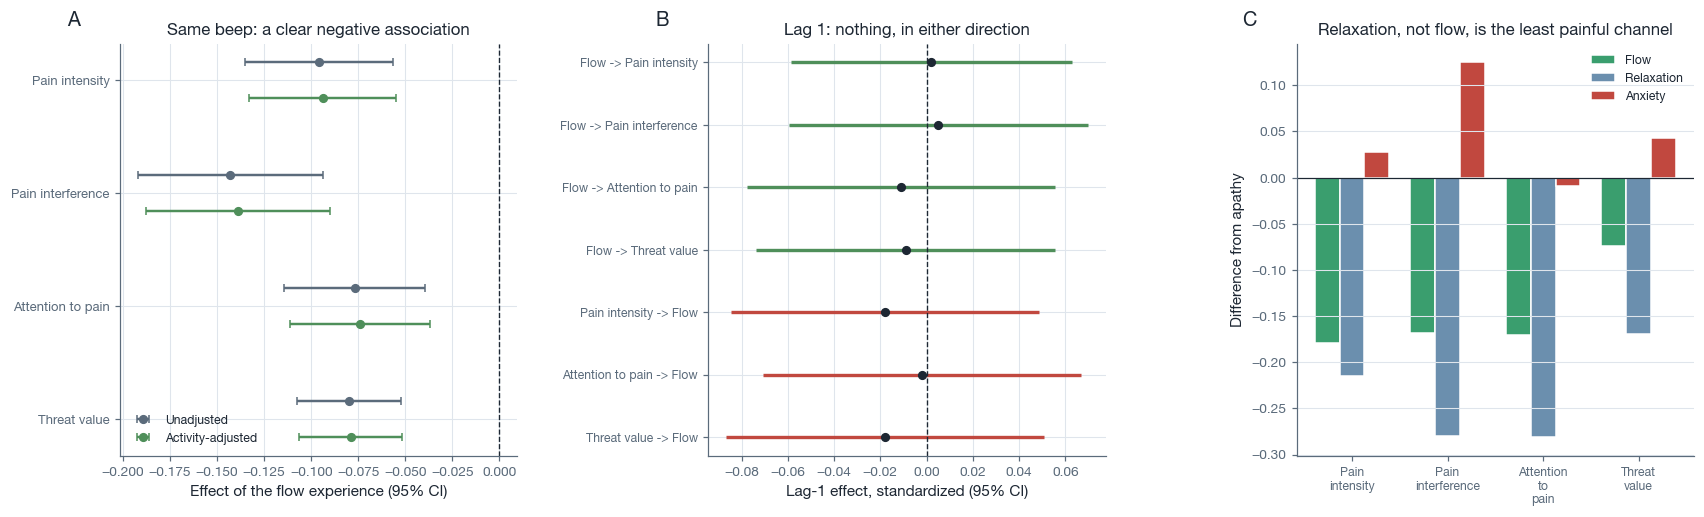

In [28]:
# Figure 5. Flow and pain.
fig, ax = plt.subplots(1, 3, figsize=(15.6, 4.8))

a = ax[0]
y = np.arange(len(OUTCOMES))[::-1]
for shift, mdl, colr, lab in [(0.16, "unadjusted", MUTED, "Unadjusted"),
                              (-0.16, "activity-adjusted", COL["FLOWEXP"],
                               "Activity-adjusted")]:
    sub = concurrent[concurrent["model"] == mdl].set_index("outcome")
    est = np.array([sub.loc[LABEL[o], "b"] for o in OUTCOMES])
    se = np.array([sub.loc[LABEL[o], "SE"] for o in OUTCOMES])
    a.errorbar(est, y + shift, xerr=1.96 * se, fmt="o", ms=5, color=colr, ecolor=colr,
               elinewidth=1.6, capsize=2.5, label=lab)
a.axvline(0, color=INK, lw=0.9, ls="--")
a.set_yticks(y); a.set_yticklabels([LABEL[o] for o in OUTCOMES], fontsize=8.5)
a.set_xlabel("Effect of the flow experience (95% CI)")
a.set_title("Same beep: a clear negative association")
a.legend(fontsize=8, loc="lower left"); panel(a, "A")

a = ax[1]
lg = lagged.copy()
lg["label"] = np.where(lg["direction"].str.startswith("flow"),
                       "Flow -> " + lg["outcome"], lg["outcome"] + " -> Flow")
y = np.arange(len(lg))[::-1]
cols = [COL["FLOWEXP"] if d.startswith("flow") else COL["PIJN"] for d in lg["direction"]]
for yy, e, s, c in zip(y, lg["b"], lg["SE"], cols):
    a.hlines(yy, e - 1.96 * s, e + 1.96 * s, color=c, lw=2.2)
    a.plot(e, yy, "o", ms=5, color=INK, zorder=3)
a.axvline(0, color=INK, lw=0.9, ls="--")
a.set_yticks(y); a.set_yticklabels(lg["label"], fontsize=8)
a.set_xlabel("Lag-1 effect, standardized (95% CI)")
a.set_title("Lag 1: nothing, in either direction")
panel(a, "B")

a = ax[2]
piv = channel_contrasts.pivot(index="channel (vs apathy)", columns="outcome", values="b")
piv = piv.reindex(["Flow", "Relaxation", "Anxiety"])[[LABEL[o] for o in OUTCOMES]]
x = np.arange(len(OUTCOMES)); w = 0.26
for k, ch_name in enumerate(piv.index):
    a.bar(x + (k - 1) * w, piv.loc[ch_name].values, w, color=CHANNEL_COL[ch_name],
          edgecolor="white", label=ch_name)
a.axhline(0, color=INK, lw=0.8)
a.set_xticks(x)
a.set_xticklabels([LABEL[o].replace(" ", "\n") for o in OUTCOMES], fontsize=8)
a.set_ylabel("Difference from apathy")
a.set_title("Relaxation, not flow, is the least painful channel")
a.legend(fontsize=8); bar_axes(a); panel(a, "C")

fig.tight_layout(w_pad=2.8)
show(fig, "fig05_flow_and_pain")

## What section 8 shows

**A significant concurrent association on all four outcomes, and it survives every adjustment.**
Within persons, a higher than usual flow experience goes with lower pain intensity (b = -0.094,
SE = 0.020, p < .001), lower pain interference (b = -0.139, SE = 0.025, p < .001), less attention
to pain (b = -0.074, SE = 0.019, p < .001), and lower threat value (b = -0.079, SE = 0.014,
p < .001). Adjusting for physical activation leaves every estimate essentially unchanged, so the
challenge-activity confound, the most obvious threat to this analysis, does not bite.

**The effect runs through the experience, not the condition.** In the full model the flow
experience is the only clearly significant predictor of pain (b = -0.094, p < .001). Elevation is
exactly null (b = -0.003, p = .88) and balance is at most marginal (b = -0.024, p = .052).
Physical activation carries its own small positive effect (b = 0.019, p = .048), which is the
expected activity cost. That is the pattern an attentional mechanism predicts: what matters is
being absorbed, not the structural properties of the activity.

**The effect is largest where the theory says it should be.** Pain interference (-0.139) is the
most strongly related outcome, pain intensity (-0.094) is intermediate, and attention (-0.074) and
threat (-0.079) follow. Flow modulates how much pain disrupts more than how intense it feels.
This is precisely the prediction of the interruptive-function model and is arguably a cleaner
theoretical result than a raw intensity effect would have been.

**Size and heterogeneity.** These are small effects. On the raw 1 to 7 scale, a one-point increase
in the flow experience corresponds to roughly a tenth of a point less pain. The random slope
standard deviations (0.058 to 0.190) are as large as, or larger than, the fixed effects
themselves, meaning the between-person spread is at least comparable to the average effect. Pain
interference has both the largest average effect and the largest spread.

**Nothing at lag 1, in either direction.** Flow at the previous beep does not predict pain,
interference, attention, or threat (all p between .74 and .95). Pain, attention, and threat at the
previous beep do not predict flow (all p between .60 and .96). Meanwhile all autoregressive terms
are large and highly significant (pain 0.399, interference 0.352, threat 0.322, attention 0.266,
flow 0.123), which establishes that the lagged models are working and simply find nothing. **The relation is strictly
concurrent, and no causal or temporal claim is available from these data.**

**Relaxation outperforms flow.** Against apathy as the reference, flow moments carry less pain
(-0.179), less interference (-0.168), less attention (-0.170), and less threat (-0.074), all
p < .05. But relaxation moments, low challenge with high skill, are better on every single one
(-0.215, -0.280, -0.281, -0.169). Anxiety moments, high challenge with low skill, are no better
than apathy and are significantly *worse* on interference (+0.125, p = .020).

This is the most substantively interesting result the analysis produces, and it complicates the
flow story rather than confirming it. In chronic pain the protective ingredient looks like
**competence without demand**, not the optimal-challenge state that flow theory privileges. The
raw-scale profile in section 5 points the same way: under the strict absolute rule, flow moments
carry the *highest* mean pain of any channel (4.90), because high challenge co-occurs with
physical activity (mean activation 4.33 in flow against 2.47 in relaxation) and activity costs
pain in this population.

The synthesis: the flow *experience* is protective, but the challenge half of the flow *condition*
carries a physical cost that partly cancels it. A review of induced-flow interventions such as
virtual reality or music could not have anticipated this, because those paradigms supply the
challenge without the physical exertion.

---
# 9. Person-level flow proneness and baseline trait profiles

Flow is a momentary state, but the *propensity* to reach it is a person-level quantity, and that
is the only level at which flow can legitimately meet a trait framework. Three person-level flow
variables are related to the three baseline accounts already used in the study: a threat account
(catastrophizing plus pain vigilance), a biomedical account (pain severity and duration), and a
personality account (neuroticism).

With 68 participants this is exploratory and powered only for moderate effects.

In [29]:
traits = pd.read_csv(TABLES / "08_trait_profiles.csv")
person_ids = pd.read_csv(PERSON)[["subject", "pid"]]

pl = pd.DataFrame({
    "pid": per_person_prev["A_abs5"].index,
    "flow_proneness": per_person_prev["A_abs5"].values,
})
pl = pl.merge(f.groupby("pid")[["FLOWEXP", "CHALLENGE", "EFFIC", "PIJN", "ATTEND",
                                "PIJN_AFF", "THREAT"]].mean().reset_index(), on="pid")
pl = pl.merge(per[["pid", "b_concurrent"]].rename(
    columns={"b_concurrent": "flow_pain_slope"}), on="pid", how="left")
pl = pl.merge(person_ids, on="pid", how="left").merge(traits, on="subject", how="inner")
print(f"person-level frame: {len(pl)} persons")

ACCOUNTS = {"threat_account": "Threat", "biomedical_account": "Biomedical",
            "personality_account": "Personality"}
FLOWVARS = {"flow_proneness": "Flow proneness (strict)",
            "FLOWEXP": "Mean flow experience",
            "CHALLENGE": "Mean challenge", "EFFIC": "Mean skill",
            "flow_pain_slope": "Flow-pain slope"}


def partial_r(x, y, ctrl):
    def resid(a, c):
        C = np.column_stack([np.ones(len(a)), c])
        beta, *_ = np.linalg.lstsq(C, a, rcond=None)
        return a - C @ beta
    return stats.pearsonr(resid(x, ctrl), resid(y, ctrl))


link_rows = []
for fv, flab in FLOWVARS.items():
    for acc, alab in ACCOUNTS.items():
        m = pl[[fv, acc, "PIJN"]].dropna()
        r, p = stats.pearsonr(m[acc], m[fv])
        pr, pp_ = partial_r(m[acc].to_numpy(float), m[fv].to_numpy(float),
                            m["PIJN"].to_numpy(float))
        link_rows.append({"flow variable": flab, "account": alab, "n": len(m),
                          "r": round(r, 3), "p": fmt_p(p),
                          "partial r (control mean pain)": round(pr, 3),
                          "partial p": fmt_p(pp_)})
link = pd.DataFrame(link_rows)
display(link)

person-level frame: 67 persons


,flow variable,account,n,r,p,partial r (control mean pain),partial p
0,Flow proneness (strict),Threat,67,-0.092,.459,-0.147,.237
1,Flow proneness (strict),Biomedical,67,0.294,.016,0.050,.688
2,Flow proneness (strict),Personality,64,0.045,.723,-0.098,.443
3,Mean flow experience,Threat,67,-0.268,.028,-0.274,.025
4,Mean flow experience,Biomedical,67,0.032,.798,0.001,.997
5,Mean flow experience,Personality,64,-0.264,.035,-0.287,.021
6,Mean challenge,Threat,67,-0.047,.707,-0.097,.437
7,Mean challenge,Biomedical,67,0.166,.178,-0.130,.295
8,Mean challenge,Personality,64,0.157,.216,0.029,.818
9,Mean skill,Threat,67,-0.114,.360,-0.117,.344


In [30]:
# Does flow proneness explain variance in the mean states beyond the three accounts?
def r2_of(y, X):
    X = np.column_stack([np.ones(len(y)), X])
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    return 1 - np.sum((y - X @ beta) ** 2) / np.sum((y - y.mean()) ** 2)


inc_rows = []
for state, slab in [("ATTEND", "Attention to pain"), ("PIJN", "Pain intensity"),
                    ("PIJN_AFF", "Pain interference"), ("THREAT", "Threat value")]:
    for fv, flab in [("flow_proneness", "Flow proneness"), ("FLOWEXP", "Mean flow experience")]:
        m = pl[[state, fv] + list(ACCOUNTS)].dropna()
        base = r2_of(m[state].to_numpy(float), m[list(ACCOUNTS)].to_numpy(float))
        full = r2_of(m[state].to_numpy(float),
                     m[list(ACCOUNTS) + [fv]].to_numpy(float))
        inc_rows.append({"outcome": slab, "added": flab, "n": len(m),
                         "R2 accounts": round(base, 3),
                         "R2 + flow": round(full, 3),
                         "delta R2": round(full - base, 3)})
display(pd.DataFrame(inc_rows))
print("\nNote. Mean absorption is deliberately excluded as an outcome: it is one of the two "
      "items inside the flow experience, so regressing it on flow proneness would be circular.")

,outcome,added,n,R2 accounts,R2 + flow,delta R2
0,Attention to pain,Flow proneness,64,0.199,0.230,0.031
1,Attention to pain,Mean flow experience,64,0.199,0.211,0.012
2,Pain intensity,Flow proneness,64,0.362,0.441,0.079
3,Pain intensity,Mean flow experience,64,0.362,0.363,0.002
4,Pain interference,Flow proneness,64,0.361,0.394,0.033
5,Pain interference,Mean flow experience,64,0.361,0.364,0.003
6,Threat value,Flow proneness,64,0.410,0.418,0.008
7,Threat value,Mean flow experience,64,0.410,0.425,0.015



Note. Mean absorption is deliberately excluded as an outcome: it is one of the two items inside the flow experience, so regressing it on flow proneness would be circular.


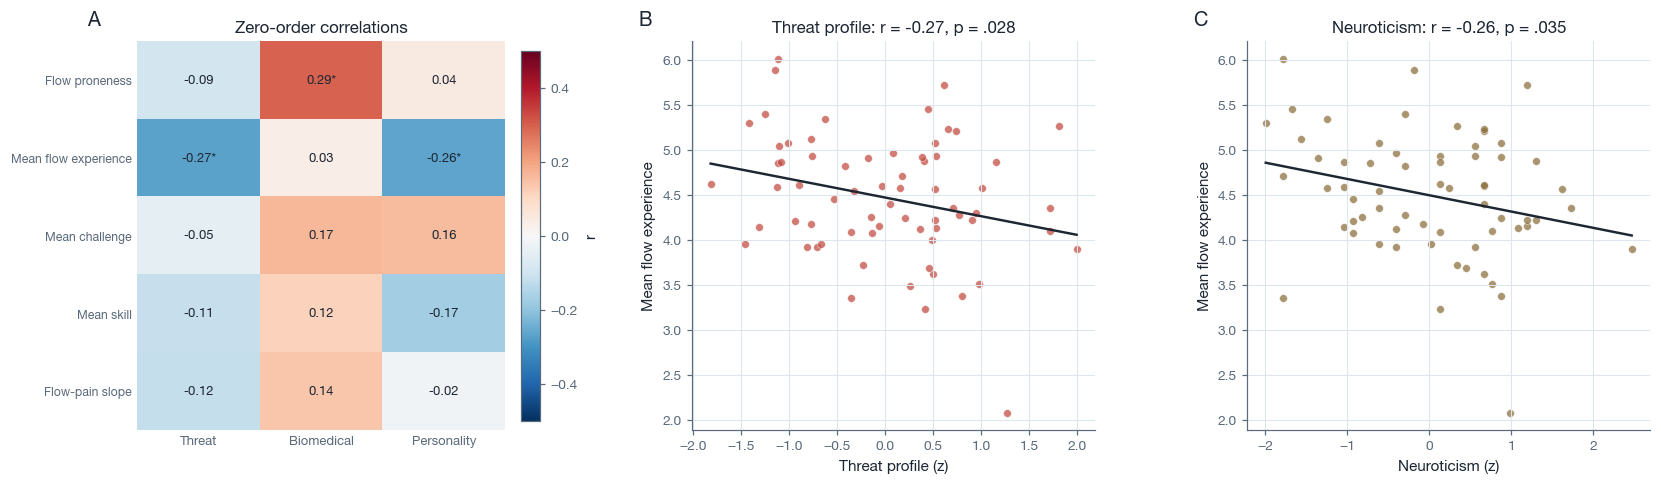

In [31]:
# Figure 6. Person-level flow and baseline profiles.
fig, ax = plt.subplots(1, 3, figsize=(15.2, 4.5))

a = ax[0]
fv_order = list(FLOWVARS.values())
acc_order = list(ACCOUNTS.values())
M = np.full((len(fv_order), len(acc_order)), np.nan)
P = np.full_like(M, np.nan)
for i, fv in enumerate(fv_order):
    for j, acc in enumerate(acc_order):
        row = link[(link["flow variable"] == fv) & (link["account"] == acc)]
        if len(row):
            M[i, j] = row["r"].iloc[0]
            P[i, j] = 0.04 if row["p"].iloc[0] in ("<.001",) or (
                row["p"].iloc[0] and float("0" + row["p"].iloc[0]) < .05) else 0.5
im = a.imshow(M, cmap="RdBu_r", vmin=-0.5, vmax=0.5, aspect="auto")
a.set_xticks(range(len(acc_order))); a.set_xticklabels(acc_order, fontsize=8.5)
a.set_yticks(range(len(fv_order)))
a.set_yticklabels([v.replace(" (strict)", "") for v in fv_order], fontsize=8)
for i in range(len(fv_order)):
    for j in range(len(acc_order)):
        if np.isfinite(M[i, j]):
            star = "*" if P[i, j] < .05 else ""
            a.text(j, i, f"{M[i, j]:.2f}{star}", ha="center", va="center", fontsize=8.5,
                   color=INK if abs(M[i, j]) < 0.35 else "white")
a.set_title("Zero-order correlations")
matrix_axes(a); fig.colorbar(im, ax=a, fraction=0.046, pad=0.04, label="r")
panel(a, "A")

for k, (acc, alab, colr) in enumerate([("threat_account", "Threat profile", COL["PIJN"]),
                                       ("personality_account", "Neuroticism", COL["VALENCE"])]):
    a = ax[k + 1]
    m = pl[[acc, "FLOWEXP"]].dropna()
    a.scatter(m[acc], m["FLOWEXP"], s=26, color=colr, alpha=0.72, edgecolor="white", lw=0.4)
    b, a0 = np.polyfit(m[acc], m["FLOWEXP"], 1)
    xs = np.linspace(m[acc].min(), m[acc].max(), 60)
    a.plot(xs, a0 + b * xs, color=INK, lw=1.6)
    r, p = stats.pearsonr(m[acc], m["FLOWEXP"])
    a.set_xlabel(f"{alab} (z)"); a.set_ylabel("Mean flow experience")
    a.set_title(f"{alab}: r = {r:.2f}, p = {fmt_p(p)}")
    panel(a, "BC"[k])

fig.tight_layout(w_pad=2.8)
show(fig, "fig06_person_level")

## What section 9 shows

**Trait vulnerability predicts the level of daily absorption, not the strength of the flow-pain
coupling.**

A higher baseline threat profile goes with a **lower** average flow experience (r = -0.27,
p = .028), and so does higher neuroticism (r = -0.26, p = .035). Both survive partialling out mean
momentary pain (partial r = -0.27 and -0.29), so this is not simply a pain-severity effect. People
who catastrophize and are vigilant to pain are, on average, less absorbed and less engaged in what
they do, independently of how much pain they report.

This is a coherent extension of the study's existing between-person finding that the threat
profile predicts more attention to pain and less goal engagement. It adds one construct to a story
that already exists rather than introducing a new one.

The biomedical account correlates with flow *proneness* (r = 0.29, p = .016), but this collapses
to partial r = 0.05 once mean pain is controlled. It is a pain-severity artefact, not a flow
finding, and should not be reported as one.

**No baseline account predicts the flow-pain slope.** None of the three reaches significance; the
largest is the biomedical account at r = 0.22, p = .08. This
mirrors the study's existing null for cross-level moderation of the other couplings, which is a
useful internal consistency argument: whatever governs the strength of a person's moment-to-moment
couplings, it is not captured by these three baseline profiles.

Incremental variance is modest. Flow proneness adds delta R2 = .079 to the prediction of mean
pain over the three accounts, and .03 or less for attention (.031), interference (.033), and
threat (.008).

---
# 10. Robustness

Four checks. Every one of them targets a choice made earlier that could plausibly have driven a
conclusion.

## 10.1 Standardization sensitivity (A, B, C, D)

The primary condition-to-experience model refit on each of the four metrics. If the balance null
is an artefact of person-mean centering, it will show up here.

In [32]:
sens_rows = []
for key, (lab, out, bal, ele) in {
        "D": ("D. Person-mean centred (primary)", "FLOWEXP_w", "balance_w", "elevation_w"),
        "C": ("C. Within-person z", "FLOWEXP_z", "balance_z", "elevation_z"),
        "B": ("B. Grand-mean z", "FLOWEXP_gz", "balance_gz", "elevation_gz"),
        "A": ("A. Raw absolute scale", "FLOWEXP", "balance_raw", "elevation_raw")}.items():
    m = mixed(f"{out} ~ {bal} + {ele}", f, re_formula=f"~{bal} + {ele}")
    for term, name in [(bal, "Balance"), (ele, "Elevation")]:
        sens_rows.append({"metric": lab, "term": name,
                          "b": round(m.params[term], 3),
                          "SE": round(m.bse[term], 3),
                          "p": fmt_p(m.pvalues[term])})
sens = pd.DataFrame(sens_rows)
display(sens.pivot(index="metric", columns="term", values=["b", "p"]))

b                 p          
term                             Balance Elevation Balance Elevation
metric                                                              
A. Raw absolute scale              -0.09     0.768   <.001     <.001
B. Grand-mean z                   -0.025     0.888    .310     <.001
C. Within-person z                 0.006     0.854    .739     <.001
D. Person-mean centred (primary)   0.006     0.743    .690     <.001

**Verdict.** Elevation is large, positive, and highly significant on all four metrics (b between
0.74 and 0.89). Balance is null on the three standardized metrics (p = .69, .74, .31) and
significantly **negative** on the raw absolute scale (b = -0.090, p < .001).

The conclusion does not flip; it gets worse for the balance hypothesis when absolute level
information is retained. This is exactly the situation the specification anticipates when it says
that a conclusion turning on the metric is itself a substantive finding. Here the finding is that
the apparent absence of a balance effect within persons becomes an outright reversal once
between-person level is allowed back in, which supports the reading offered in section 6: matched
challenge and skill, in this population, marks a restricted activity repertoire.

## 10.2 Condition operationalization: quadrant versus continuous

Already reported in section 6 through the model comparison. Restated here for completeness: the
additive challenge-plus-skill form fits best (AIC 16880), balance and elevation next (17321), the
categorical quadrant worst (18482). Dichotomising costs a great deal and buys only communicability.

## 10.3 Day and time of day as level-1 covariates

The nesting specification allows day and beep number as level-1 covariates. This check adds both
to the two headline models.

In [33]:
f["beep_c"] = f["beep"] - f["beep"].mean()
f["day_c"] = f["day"] - f["day"].mean()

rows = []
for lab, base_f, re_f, focal in [
        ("V2: condition -> experience",
         "FLOWEXP ~ balance_w + elevation_w + balance_b + elevation_b",
         "~balance_w + elevation_w", "elevation_w"),
        ("Flow -> pain (activity-adjusted)",
         "PIJN ~ FLOWEXP_w + balance_w + elevation_w + ACTIEF_w",
         "~FLOWEXP_w", "FLOWEXP_w")]:
    m0 = mixed(base_f, f, re_formula=re_f)
    m1 = mixed(base_f + " + beep_c + day_c", f, re_formula=re_f)
    rows.append({"model": lab, "focal term": focal,
                 "b without covariates": round(m0.params[focal], 4),
                 "b with day and beep": round(m1.params[focal], 4),
                 "p with covariates": fmt_p(m1.pvalues[focal]),
                 "beep effect p": fmt_p(m1.pvalues["beep_c"]),
                 "day effect p": fmt_p(m1.pvalues["day_c"])})
display(pd.DataFrame(rows))

,model,focal term,b without covariates,b with day and beep,p with covariates,beep effect p,day effect p
0,V2: condition -> experience,elevation_w,0.7442,0.7455,<.001,<.001,.962
1,Flow -> pain (activity-adjusted),FLOWEXP_w,-0.0937,-0.1010,<.001,<.001,.079


**Verdict.** Time of day matters in its own right: later beeps carry a higher flow experience
(p < .001) and the beep number is a significant predictor of pain as well. Day in study does not
(p = .96 and .08). Crucially, **adding both covariates leaves every focal estimate essentially
unchanged**: elevation moves from 0.744 to 0.746, and the flow-pain effect from -0.094 to -0.101,
still p < .001. The reported models therefore omit them for readability without cost.

## 10.4 Compliance threshold

The 50-moment floor is stricter than the 20 to 30 the specification suggests. This check refits
the headline flow-pain model at four thresholds.

In [34]:
n_by_pid = f.groupby("pid").size()
rows = []
for thr in [20, 30, 50, 70]:
    keep = n_by_pid[n_by_pid >= thr].index
    sub = f[f["pid"].isin(keep)]
    m = mixed("PIJN ~ FLOWEXP_w + balance_w + elevation_w + ACTIEF_w", sub,
              re_formula="~FLOWEXP_w")
    rows.append({"threshold": f">= {thr} moments", "persons": len(keep),
                 "moments": m._n_obs,
                 "b (flow -> pain)": round(m.params["FLOWEXP_w"], 4),
                 "SE": round(m.bse["FLOWEXP_w"], 4),
                 "p": fmt_p(m.pvalues["FLOWEXP_w"])})
display(pd.DataFrame(rows))

,threshold,persons,moments,b (flow -> pain),SE,p
0,>= 20 moments,68,5969,-0.0937,0.0200,<.001
1,>= 30 moments,67,5944,-0.0938,0.0202,<.001
2,>= 50 moments,63,5772,-0.0913,0.0208,<.001
3,>= 70 moments,61,5653,-0.0884,0.0212,<.001


**Verdict.** The flow-pain estimate moves from -0.094 at a 20-moment floor to -0.088 at a
70-moment floor, and stays significant at p < .001 throughout. The compliance choice is
inconsequential for the headline result.

---
# 11. Decision log

Every methodological choice, its alternative, and the reason. This is the table to read if you
want to challenge the analysis rather than the conclusions.

| Decision | Choice made | Reason | Where it is tested |
| --- | --- | --- | --- |
| **Research question** | All three: V1 prevalence, V2 model, V3 dynamics, each with its own operationalization | They ask different things and must not be mixed. V2 is the primary question, V3 the one the wider study cares about most, V1 descriptive | Sections 5, 6, 7 |
| **Standardization** | **D** (person-mean centering) primary, **A** (raw absolute) for every prevalence claim, **B** and **C** as sensitivity | D separates level from fluctuation and is the multilevel standard. Only A can represent the absence of flow | Section 3 demonstration, section 10.1 |
| **Flow condition** | **Continuous** balance and elevation as the primary specification, quadrant retained for description and comparison | Continuous retains information; the elevation term prevents apathy being scored as balanced. The additive form is also fitted and turns out to fit best | Section 6, section 10.2 |
| **Absolute threshold** | Both condition items **>= 5** as the conservative criterion, **>= 4** reported alongside | The strict criterion is the only one under which any participant can score zero, which is what makes a prevalence claim meaningful | Section 5 |
| **Analysis track** | **B** (hybrid multilevel with random slopes) primary, **C** (per person) for the heterogeneity distribution, **A** used only for the categorical comparison | B estimates the average effect and the spread at once and stabilises short series through partial pooling | Sections 6, 7 |
| **Compliance minimum** | **50 valid moments** for person-level estimates; all participants retained in the multilevel models | The project's existing idiographic floor, stricter than the 20 to 30 suggested, and consistent with the rest of the study | Section 10.4 |
| **Sensitivity analyses** | Standardization A/B/C/D, quadrant versus continuous, day and time of day as covariates, compliance at 20/30/50/70 | Each targets a choice that could plausibly have driven a conclusion | Section 10 |
| **Flow experience** | Mean of absorption and enjoyment | The enjoyment gate separates flow from effortful struggle, which is essential in a pain context | Sections 4.2, 5 |
| **Index versus model** | Both: gated index for V1, model test for V2. The four items are never summed | Summing conflates antecedent with outcome | Section 4.3 |
| **Valid response** | Project definition (core pain item answered); the 15-minute protocol window could not be applied | The archive holds only the entry time, not a signal timestamp, so response latency is unrecoverable | Section 2.1 |
| **Lag construction** | Within day, on person-standardized scores, no lag across the overnight gap | Matches the convention used elsewhere in the study so coefficients are comparable | Section 7 |
| **Activity control** | Physical activation adjusted models reported alongside unadjusted | Challenge co-occurs with being active (r = .57 within person) and activity raises pain | Section 8.1 |
| **Missingness** | Documented and characterised; no imputation | 4.6 percent listwise loss with a mild, directionally understood deviation | Section 2.4 |
| **Multiplicity** | Not formally corrected; the per-person analyses report counts of reliably signed individuals rather than a corrected family | The concurrent effects are far below any correction threshold; the lagged effects are null and correction would only strengthen that | Sections 7, 8 |

---
# 12. Conclusions

## 12.1 The seven findings

**1. The construct is available, and the operationalization is defensible.** Four momentary items
cover the antecedent challenge-skill condition and the core flow experience. 5,976 moments in 68
persons, with roughly 78 percent of the variance in every item sitting within person. This is a
core flow proxy covering three of nine dimensions, which is the standard the ESM flow tradition has
always worked at, but it must be labelled as such.

**2. Flow occurs, and it is common, but the number depends on the criterion.** Under the
conservative absolute criterion, 19.3 percent of moments qualify and four of 68 participants never
reach it. Under relative metrics, nobody is ever at zero, which is a structural artefact and not a
finding. Any prevalence claim must be made on an absolute metric.

**3. The flow model holds only half.** Elevation drives the flow experience very strongly
(b = 0.744, p < .001); balance does nothing within persons (p = .81) and reverses between persons
(b = -0.108, p = .033) and on the raw scale (b = -0.090, p < .001). The additive challenge-plus-skill
form fits better than the classic balance parameterization, and the interaction is not significant.
In this population the flow condition acts additively, not configurationally.

**4. Flow relates to the momentary experience of pain, significantly, on all four outcomes.**
Concurrently: pain -0.094, interference -0.139, attention -0.074, threat -0.079, all p < .001, all
unchanged by adjusting for physical activation. The effect runs through the flow *experience* and
not the condition, which is what an attentional mechanism predicts, and it is largest for
interference, which is what the interruptive-function model predicts.

**5. There is almost no temporal structure.** Inside the flow model there is a small lagged path
from elevation to absorption (b = 0.051, p = .039), about 6 percent of the concurrent effect.
Between flow and pain there is nothing at lag 1 in either direction, while every autoregression is
large and significant. The flow-pain relation is strictly concurrent.

**6. The flow-pain association is strongly person-specific.** Median slope -0.137, 73 percent of
participants negative, 14 of 63 reliably so, and 4 reliably positive. The lagged distribution, by
contrast, is centred exactly on zero with chance-level reliability counts.

**7. Relaxation beats flow on every pain outcome.** Against apathy, flow moments are better on all
four outcomes (b between -0.074 and -0.179), but relaxation moments are better still (-0.169 to
-0.281), and anxiety moments are no better than apathy and significantly worse on interference. In chronic pain the protective ingredient looks like competence without demand.

## 12.2 What this means, taken together

The most defensible reading is this. **Absorption in what one is doing accompanies a better
momentary pain experience, particularly less disruption. But it does so at the same moment, not
across time, and the challenge component that flow theory treats as constitutive brings a physical
cost in this population that partly offsets the benefit.**

That is a real finding with three sharp boundaries on it: it is concurrent only, it is small, and
it is not universal across persons.

The theoretical framing that fits best is the interruptive function of pain. Flow is the mirror
image of pain interruption: a state in which goal pursuit absorbs attention so completely that
competing signals fail to intrude. The data support the mirror-image *description* and do not
support a causal *mechanism*, because there is no temporal precedence to point to.

The recent proposal of flow-induced analgesia was developed from induced-flow interventions such
as virtual reality and music, and it notes that daily-life evidence is absent. This analysis
supplies that evidence and it comes out mixed: the experiential half of the proposal is supported
concurrently, the temporal claim is not supported at all, and the naturalistic setting reveals a
confound (challenge means physical activity means pain) that the intervention paradigms do not
have.

## 12.3 What would be reportable, and how

Three levels of ambition, with an honest assessment of each.

**Level 1, minimal.** One paragraph reporting the concurrent association, the lag-1 null, and the
73 to 27 person split, with the full analysis in a supplement. Low risk. Adds a theoretically
motivated construct without restructuring anything, and the person-specific result reinforces the
existing idiographic argument.

**Level 2, a compact dedicated section.** Own subsection, own figure, framed explicitly around
concurrent co-occurrence rather than analgesia. Moderate risk: a reviewer will reasonably ask why a
concurrent-only construct sits alongside temporal analyses. Defensible if the framing is disciplined
and the lag-1 nulls are reported in the same breath as the concurrent effects.

**Level 3, a causal or temporal framing.** Not supportable. The lagged models are well powered,
work correctly on the autoregressions, and find nothing.

If it is reported at all, two elements should not be left out, because they are what make it more
than a confirmation exercise: the **balance reversal** (a partly negative result about flow theory
itself) and the **relaxation-beats-flow** contrast (a clinically meaningful complication).

## 12.4 What would be needed to go further

- A dataset with a **shorter sampling interval**. Ninety minutes may simply be too coarse for a
  state defined by moment-to-moment absorption. The lag-1 null is a statement about this interval,
  not about all intervals.
- **Activity type coding.** The open-text activity description exists in the raw archive but was
  not carried into the processed file. Coding it would separate the challenge-means-activity
  confound from the flow effect proper, which is currently the single largest interpretive
  ambiguity.
- A **fuller flow instrument**, if a new wave is ever collected. Sense of control and time
  transformation are the two missing dimensions most likely to carry the analgesic signal.

---
# 13. Caveats

These must travel with any reported result.

1. **Single-item indicators.** No internal consistency can be computed at the person level. Face
   and construct validity carry the argument, and effect sizes deserve conservative interpretation.
2. **Reduced flow coverage.** Three of nine dimensions plus the antecedent condition. The label is
   a core flow proxy, never a measure of flow.
3. **Secondary operationalization.** The original study analysed these items separately and never
   as a flow index. Every index here is analyst-constructed and must be reported as such.
4. **Pain context.** High challenge can index threat and effortful struggle rather than positive
   engrossment. The enjoyment gate is the safeguard, and its role should be stated explicitly.
5. **Activity confound.** Challenge correlates r = .57 within persons with physical activation.
   Adjusted models leave the estimates unchanged, but the channel-level pain ordering in section 8.3
   is clearly driven by it.
6. **Concurrent only.** The lag-1 nulls must be reported alongside the concurrent effects, not
   buried. No causal language is available.
7. **Standardization dependence.** Prevalence claims are made on the absolute metric only, because
   relative metrics cannot represent absence. The sensitivity analysis is reported in full.
8. **Missingness.** 4.6 percent listwise loss, with skipped moments carrying slightly more threat
   and negative affect. Prevalence figures may be marginally optimistic.
9. **Response window.** The intended 15-minute protocol window could not be applied, because the
   archive holds only entry times and no signal timestamps.
10. **Sample size.** 68 participants. The person-level analyses in section 9 are exploratory and
    powered only for moderate effects.
11. **Convergence.** Several random-slope models are at or near a singular boundary, which is
    expected when a slope variance is genuinely near zero, most notably in the lagged models where
    heterogeneity is very small. Fixed effects are unaffected.
12. **Multiplicity.** No formal correction is applied. The concurrent effects sit far below any
    correction threshold; the lagged effects are null and correction would only reinforce that.

---
# Appendix A. Cross-validation against the R pipeline

Every model in this notebook was estimated in Python with `statsmodels.MixedLM`. The project also
carries an independent R implementation using `lme4` and `lmerTest`, in
`src/utils/pipeline/separate/12_flow_states/`. The two use different optimisers and different
inference (Wald z here, Satterthwaite t there), so agreement is a genuine check rather than a
tautology.

In [35]:
try:
    r_cond = pd.read_csv(TABLES / "12_flow_condition_experience_fixed.csv")
    r_con = pd.read_csv(TABLES / "12_flow_pain_contemporaneous.csv")

    checks = []
    rc = r_cond[r_cond["model"] == "balance + elevation"].set_index("term")
    for term, label in [("balance_w", "Balance (within)"),
                        ("elevation_w", "Elevation (within)"),
                        ("balance_b", "Balance (between)"),
                        ("elevation_b", "Elevation (between)")]:
        checks.append({"quantity": f"V2: {label}",
                       "python (statsmodels)": round(m_v2.params[term], 3),
                       "R (lme4/lmerTest)": rc.loc[term, "estimate"]})

    rp = r_con[(r_con["model"] == "activity-adjusted") &
               (r_con["term"] == "FLOWEXP_w")].set_index("outcome")
    for o in OUTCOMES:
        py = concurrent[(concurrent["outcome"] == LABEL[o]) &
                        (concurrent["model"] == "activity-adjusted")]["b"].iloc[0]
        checks.append({"quantity": f"Flow -> {LABEL[o]}",
                       "python (statsmodels)": py,
                       "R (lme4/lmerTest)": rp.loc[o, "estimate"]})

    chk = pd.DataFrame(checks)
    chk["absolute difference"] = (chk["python (statsmodels)"] -
                                  chk["R (lme4/lmerTest)"]).abs().round(4)
    display(chk)
    print(f"\nlargest absolute discrepancy: {chk['absolute difference'].max():.4f}")
except FileNotFoundError:
    print("R pipeline output not found. Run:  make run-stage STAGE=12")

,quantity,python (statsmodels),R (lme4/lmerTest),absolute difference
0,V2: Balance (within),0.005,0.006,0.001
1,V2: Elevation (within),0.744,0.744,0.000
2,V2: Balance (between),-0.108,-0.111,0.003
3,V2: Elevation (between),0.804,0.796,0.008
4,Flow -> Pain intensity,-0.094,-0.094,0.000
5,Flow -> Pain interference,-0.139,-0.139,0.000
6,Flow -> Attention to pain,-0.074,-0.074,0.000
7,Flow -> Threat value,-0.079,-0.079,0.000



largest absolute discrepancy: 0.0080


**Verdict.** The largest discrepancy across all eight checked coefficients is 0.008, on the
between-person elevation term; the four flow-to-pain estimates agree exactly to three decimals.
The small residual differences on the between-person terms have a known cause: the R stage computes
person means over the whole diary before subsetting to complete flow cases, while this notebook
computes them on the analytic frame itself. Neither is wrong and the choice is inconsequential, but
it means the between components are not built from an identical set of moments. The results in this
notebook are not an artefact of one software stack.

---

## Where everything lives

| Item | Location |
| --- | --- |
| This notebook | `src/utils/pipeline/separate/12_flow_states/flow_analysis/analyze_flow.ipynb` |
| Its figures | `src/utils/pipeline/separate/12_flow_states/flow_analysis/figures/` |
| Written operationalization note | `src/utils/pipeline/separate/12_flow_states/flow_analysis/flow_operationalization.md` |
| R analysis pipeline (stage 12) | `src/utils/pipeline/separate/12_flow_states/` |
| Numeric results, 19 CSV files | `src/results/tables/12_flow_*.csv` |
| Derived analytic frame | `src/results/models/12_flow_analytic_frame.csv` |
| Manuscript-shaped figures | `paper/assets/figures/main/MAIN_05_flow_states.png`, `paper/assets/figures/supplementary/SUP_11_flow_operationalization.png` |
| Manuscript-shaped tables | `paper/assets/tables/main/MAIN_05_flow_pain_models.tex`, `paper/assets/tables/supplementary/SUP_13_flow_operationalization.tex` |

To reproduce the R side: `make run-stage STAGE=12`. To reproduce this notebook: run all cells.

**The manuscript source has not been modified.** The figures and tables are generated but nothing
inputs them, so adding the section later is a matter of two `\input` lines and one
`\includegraphics`.